In [ ]:
# ============================================================================
# Full script: QC v0.9.0 + PQO + AD-SAFE STRETCHED DRIFT
#   - Shape: Gaussian-Filtered Square (Preserved via Fourier)
#   - Fix: Lower Fourier Order (K=20) to prevent Gradient Explosion
#   - Fix: Differentiable T_total for pulse stretching
# ============================================================================

import Pkg
Pkg.activate(".")

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using FFTW
using CairoMakie
using CSV, DataFrames
using ForwardDiff
using Statistics

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 1
Random.seed!(seed)

T        = 60           # Slightly more steps helps convergence for smooth shapes
Δt_guess = 1.0          
num_iter = 1000
F_target = 0.9999

u_bound   = 5.0          
ddu_bound = 10.0         
Q = 1.0

piccolo_opts = PiccoloOptions(verbose=false, timesteps_all_equal=true)
T_total0 = (T - 1) * Δt_guess

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I; Y1 = GATES.Y ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X; Y2 = GATES.I ⊗ GATES.Y
H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)
H_fixed_op  = (GATES.X ⊗ GATES.X + GATES.Y ⊗ GATES.Y) / 2

H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# Target iSWAP
U_goal = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))

# =============================================================================
# Build Gaussian Square Shape (STABILIZED)
# =============================================================================
pre_ns, pulse_ns, post_ns = 15.0, 50.0, 15.0
total_ns = pre_ns + pulse_ns + post_ns
sq_dt_fine_s = 0.05e-9
sq_N_fine = Int(round(total_ns * 1e-9 / sq_dt_fine_s))
sq_u_zoh = zeros(sq_N_fine)

i_start = Int(round(pre_ns / 0.05)) + 1
i_end   = i_start + Int(round(pulse_ns / 0.05)) - 1
sq_u_zoh[i_start:i_end] .= 1.0

# Apply Gaussian Filter (250 MHz)
function fftfreq(N, dt)
    df = 1.0 / (N * dt)
    return df .* [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
end

sq_freqs  = fftfreq(sq_N_fine, sq_dt_fine_s)
sq_filter = @. exp(-0.5 * (sq_freqs^2) / (250e6 / sqrt(log(2.0)))^2)
sq_u_out  = real.(ifft(sq_filter .* fft(sq_u_zoh)))
sq_u_out .-= minimum(sq_u_out)
sq_u_out ./= (maximum(sq_u_out) + 1e-12)

# Fit Fourier with K=20 (K=60 causes gradient explosion in Ipopt)
function make_fourier_coefficients(u::Vector{Float64}; K::Int=20)
    N = length(u)
    u0 = u .- mean(u)
    U = fft(u0) / N
    a0 = real(U[1])
    a = [2 * real(U[m+1]) for m in 1:K]
    b = [-2 * imag(U[m+1]) for m in 1:K]
    return a0, a, b
end

A0, A_coeffs, B_coeffs = make_fourier_coefficients(sq_u_out; K=20)

# Differentiable Fourier Evaluator
function eval_fourier(s, a0, a, b)
    val = a0
    for m in 1:length(a)
        θ = 2π * m * s
        val += a[m] * cos(θ) + b[m] * sin(θ)
    end
    return val
end

# Normalization factors for the Fourier series
probe_s = range(0.0, 1.0, length=1000)
probe_u = [eval_fourier(si, A0, A_coeffs, B_coeffs) for si in probe_s]
F_min, F_max = minimum(probe_u), maximum(probe_u)

shape_fun = (s) -> (eval_fourier(s, A0, A_coeffs, B_coeffs) - F_min) / (F_max - F_min + 1e-12)

# =============================================================================
# AD-SAFE Hamiltonian & System
# =============================================================================
drift_peak = 2π * 0.05
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    traj = traj_ref[]
    # Use the trajectory's Δt if available to allow stretching via AD
    dt_var = isnothing(traj) ? Treal(Δt_guess) : Treal(traj[:Δt][1])
    
    T_total = dt_var * (T - 1)
    s = clamp(t / (T_total + 1e-12), zero(Treal), one(Treal))

    amp = Treal(drift_peak) * shape_fun(s)

    Tc = Complex{Treal}
    Ht = Tc.(H_fixed_opC) .* amp
    for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end
    return Ht
end

drive_bounds = fill((-u_bound, u_bound), n_drives)
sys = QuantumSystem(H_time, T_total0, drive_bounds)

# =============================================================================
# Problem Construction & Solve
# =============================================================================
def_prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt_guess;
    Δt_max = 5.0 * Δt_guess,
    Δt_min = 0.2 * Δt_guess,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q,
    piccolo_options = piccolo_opts
)

traj_ref[] = def_prob.trajectory

push!(def_prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, def_prob.trajectory)
)

println("\nStarting Solve (Fourier K=20)...")
solve!(def_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

# =============================================================================
# Results & Plotting
# =============================================================================
F_final = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("\nFinal Fidelity: $F_final")

times = get_times(def_prob.trajectory)
T_final = times[end]
t_plot = range(0.0, T_final, length=1000)
g_eff = [drift_peak * shape_fun(tt/T_final) for tt in t_plot]

fig = Figure(size=(800, 400))
ax = Axis(fig[1,1], title="Optimized Stretched Gaussian-Square Drift", xlabel="Time (ns)", ylabel="g_eff(t)")
lines!(ax, t_plot, g_eff, linewidth=3, color=:blue)
save("gaussian_square_stretched.png", fig)
display(fig)

In [ ]:
# ============================================================================
# Full script: STABILIZED FOURIER (K=15) + HIGH FIDELITY FIX
#   - Method: Fourier Series (Proven stable gradients in your logs)
#   - Fix 1: Q = 400.0 (Forces solver to target F=0.9999, fixing bad fidelity)
#   - Fix 2: K = 15 (Smoother than 20, easier for optimizer)
# ============================================================================

import Pkg
Pkg.activate(".")

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using FFTW
using CairoMakie
using CSV, DataFrames
using ForwardDiff
using Statistics

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 2  # Changed seed slightly to avoid previous bad local minima
Random.seed!(seed)

T        = 60           
Δt_guess = 1.0          
num_iter = 5000
F_target = 0.9999

u_bound   = 5.0          
ddu_bound = 10.0         
Q         = 400.0  # <--- CRITICAL FIX: High weight forces High Fidelity

piccolo_opts = PiccoloOptions(verbose=false, timesteps_all_equal=true)
T_total0 = (T - 1) * Δt_guess

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I; Y1 = GATES.Y ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X; Y2 = GATES.I ⊗ GATES.Y
H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)
H_fixed_op  = (GATES.X ⊗ GATES.X + GATES.Y ⊗ GATES.Y) / 2

H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# Target iSWAP
U_goal = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))

# =============================================================================
# Build Gaussian Square Shape (FOURIER)
# =============================================================================
pre_ns, pulse_ns, post_ns = 15.0, 50.0, 15.0
total_ns = pre_ns + pulse_ns + post_ns
sq_dt_fine_s = 0.05e-9
sq_N_fine = Int(round(total_ns * 1e-9 / sq_dt_fine_s))
sq_u_zoh = zeros(sq_N_fine)

i_start = Int(round(pre_ns / 0.05)) + 1
i_end   = i_start + Int(round(pulse_ns / 0.05)) - 1
sq_u_zoh[i_start:i_end] .= 1.0

# Apply Gaussian Filter (250 MHz)
function fftfreq(N, dt)
    df = 1.0 / (N * dt)
    return df .* [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
end

sq_freqs  = fftfreq(sq_N_fine, sq_dt_fine_s)
sq_filter = @. exp(-0.5 * (sq_freqs^2) / (250e6 / sqrt(log(2.0)))^2)
sq_u_out  = real.(ifft(sq_filter .* fft(sq_u_zoh)))
sq_u_out .-= minimum(sq_u_out)
sq_u_out ./= (maximum(sq_u_out) + 1e-12)

# Fit Fourier with K=15 (Reduced from 20 for better stability)
function make_fourier_coefficients(u::Vector{Float64}; K::Int=15)
    N = length(u)
    u0 = u .- mean(u)
    U = fft(u0) / N
    a0 = real(U[1])
    a = [2 * real(U[m+1]) for m in 1:K]
    b = [-2 * imag(U[m+1]) for m in 1:K]
    return a0, a, b
end

A0, A_coeffs, B_coeffs = make_fourier_coefficients(sq_u_out; K=15)

# Differentiable Fourier Evaluator
function eval_fourier(s, a0, a, b)
    val = a0
    for m in 1:length(a)
        θ = 2π * m * s
        val += a[m] * cos(θ) + b[m] * sin(θ)
    end
    return val
end

# Normalization
probe_s = range(0.0, 1.0, length=1000)
probe_u = [eval_fourier(si, A0, A_coeffs, B_coeffs) for si in probe_s]
F_min, F_max = minimum(probe_u), maximum(probe_u)
shape_fun = (s) -> (eval_fourier(s, A0, A_coeffs, B_coeffs) - F_min) / (F_max - F_min + 1e-12)

# =============================================================================
# AD-SAFE Hamiltonian & System
# =============================================================================
drift_peak = 2π * 0.05 # 50 MHz peak drift
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    traj = traj_ref[]
    dt_var = isnothing(traj) ? Treal(Δt_guess) : Treal(traj[:Δt][1])
    
    T_total = dt_var * (T - 1)
    s = clamp(t / (T_total + 1e-12), zero(Treal), one(Treal))

    # Fourier evaluation is safe for AD
    amp = Treal(drift_peak) * shape_fun(s)

    Tc = Complex{Treal}
    Ht = Tc.(H_fixed_opC) .* amp
    for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end
    return Ht
end

drive_bounds = fill((-u_bound, u_bound), n_drives)
sys = QuantumSystem(H_time, T_total0, drive_bounds)

# =============================================================================
# Problem Construction
# =============================================================================
prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt_guess;
    Δt_max = 5.0 * Δt_guess,
    Δt_min = 0.2 * Δt_guess,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q, # Using Q=400.0
    piccolo_options = piccolo_opts
)

traj_ref[] = prob.trajectory

push!(prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, prob.trajectory)
)

# =============================================================================
# Solve
# =============================================================================
println("\nStarting Solve (Fourier K=15, Q=400)...")
solve!(prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

# =============================================================================
# Results
# =============================================================================
F_final = unitary_rollout_fidelity(prob.trajectory, sys)
dt_final = prob.trajectory[:Δt][1]
T_final_val = (T-1) * dt_final

println("\nFinal Fidelity: $F_final")
println("Final Gate Duration: $T_final_val ns")
println("Final Δt: $dt_final ns")

times = get_times(prob.trajectory)
t_plot = range(0.0, times[end], length=1000)
g_eff = [drift_peak * shape_fun(tt/times[end]) for tt in t_plot]

fig = Figure(size=(800, 400))
ax = Axis(fig[1,1], title="Optimized Stretched Fourier Drift (K=15)", xlabel="Time (ns)", ylabel="g_eff(t)")
lines!(ax, t_plot, g_eff, linewidth=3, color=:blue)
display(fig)

In [ ]:
# =============================================================================
# QUICK CHECK: min/max drift AREA given allowed Δt range
# =============================================================================
function trapz(x::AbstractVector, y::AbstractVector)
    s = zero(eltype(y))
    @inbounds for i in 1:length(x)-1
        s += 0.5 * (y[i] + y[i+1]) * (x[i+1] - x[i])
    end
    return s
end

# --- compute Ashape = ∫_0^1 shape_fun(s) ds ---
Ns = 20000
s_chk = collect(range(0.0, 1.0; length=Ns))
shape_vals = [shape_fun(si) for si in s_chk]
Ashape = trapz(s_chk, shape_vals)

# --- your allowed Δt range ---
Δt_min = 0.5 * Δt
Δt_max = 40.0 * Δt

Tcur_min = (T - 1) * Δt_min
Tcur_max = (T - 1) * Δt_max

Θ_min = drift_peak * Tcur_min * Ashape
Θ_max = drift_peak * Tcur_max * Ashape

println("\n============= Δt-RANGE DRIFT AREA CHECK =============")
println("shape area Ashape = ∫_0^1 shape_fun(s) ds = $Ashape")
println("Δt range: [$Δt_min, $Δt_max]")
println("Tcur range: [$Tcur_min, $Tcur_max]")

println("\nΘ_min = drift_peak*Tcur_min*Ashape = $Θ_min rad")
println("Θ_max = drift_peak*Tcur_max*Ashape = $Θ_max rad")

# effective entangling angle on (XX+YY) because H_fixed=(XX+YY)/2
println("\nEffective angle on (XX+YY):")
println("  (Θ_min)/2 = $(Θ_min/2)")
println("  (Θ_max)/2 = $(Θ_max/2)")

println("\nCompare to iSWAP target |Θ| ≈ π/2 = $(π/2):")
println("  |Θ_min|/(π/2) = $(abs(Θ_min)/(π/2))")
println("  |Θ_max|/(π/2) = $(abs(Θ_max)/(π/2))")
println("====================================================\n")

In [ ]:
# ============================================================================
# Full working script: QC v0.9.0 + PQO function-system, time-dependent drift
# TEST CASE: drift is CONSTANT-ON for the ENTIRE horizon (NO OFF TIME)
# - Same plumbing as before
# - ForwardDiff-safe time-dependent drift Hamiltonian
# - Fixes 2π scaling
# - Plots final g_eff(t)
# ============================================================================

import Pkg
Pkg.activate(".")
Pkg.instantiate()

using PiccoloQuantumObjects
using QuantumCollocation
using LinearAlgebra
using SparseArrays
using Random
using NamedTrajectories
using CairoMakie
using CSV, DataFrames
using ForwardDiff

⊗ = kron

# =============================================================================
# Parameters
# =============================================================================
seed = 1
Random.seed!(seed)

T        = 50
Δt       = 0.2
num_iter = 1000
F_target = 0.9999

# bounds (MUST go into QuantumSystem via drive_bounds in your QC version)
u_bound   = 5.0
ddu_bound = 10.0

# objective weight
Q = 1.0

piccolo_opts = PiccoloOptions(
    verbose=false,
    timesteps_all_equal=true
)

# fallback total duration before any trajectory exists
T_total0 = (T - 1) * Δt
println("============| seed=$seed, T=$T, Δt=$Δt, T_total0=$T_total0 |============")

# =============================================================================
# Operators (2-qubit)
# =============================================================================
X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z

XX = GATES.X ⊗ GATES.X
YY = GATES.Y ⊗ GATES.Y

H_drive_ops = [X1, Y1, X2, Y2]
n_drives    = length(H_drive_ops)

# drift operator that gets scaled by g_eff(t)
H_fixed_op = (XX + YY) / 2

# convert to ComplexF64 once
H_fixed_opC = ComplexF64.(H_fixed_op)
H_driveC    = [ComplexF64.(H) for H in H_drive_ops]

# target iSWAP
iSWAP  = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
U_goal = iSWAP

# =============================================================================
# Drift profile: ALWAYS ON
# =============================================================================
drift_peak = 2π * 0.05   # <-- include 2π scaling here (same as your other case)

# fixed index profile (optimizer sees this by index)
g_profile = fill(drift_peak, T)

println("drift_peak = $drift_peak")
println("g_profile is CONSTANT-ON across all k = 1:$T")

# =============================================================================
# Plot g_eff vs INDEX (before optimization)
# =============================================================================
k = collect(1:T)

fig_pre = Figure(size=(950, 420))
ax_pre = Axis(fig_pre[1,1];
    xlabel="index k",
    ylabel="g_eff[k]",
    title="g_eff BEFORE optimization (index domain): ALWAYS ON"
)

lines!(ax_pre, k, g_profile; linewidth=3, label="g_profile[k] = constant drift_peak")
scatter!(ax_pre, k, g_profile; markersize=5)

axislegend(ax_pre; position=:rt)
save("g_eff_before_opt_index_always_on.png", fig_pre)
display(fig_pre)
println("Saved g_eff_before_opt_index_always_on.png")

# =============================================================================
# Helpers: Dual-safe extraction of real value
# =============================================================================
_real(x::Real) = x
_real(x::ForwardDiff.Dual) = ForwardDiff.value(x)

# =============================================================================
# t -> index mapping (stretches with total duration Tcur)
# =============================================================================
function time_to_index(t_real::Real, Tcur::Real, T::Int)
    s = clamp(t_real / Tcur, 0.0, 1.0)
    return clamp(Int(floor(s * (T - 1))) + 1, 1, T)
end

# =============================================================================
# trajectory reference so Tcur updates after the problem exists
# =============================================================================
traj_ref = Ref{Union{NamedTrajectory, Nothing}}(nothing)

# =============================================================================
# Time-indexed drift Hamiltonian H(u,t) (ForwardDiff-safe)
# =============================================================================
function H_time(u::AbstractVector{Treal}, t::Real) where {Treal<:Real}
    # duration in real scalar (Float64)
    Tcur = T_total0
    if !isnothing(traj_ref[])
        Tcur = get_times(traj_ref[])[end]
    end
    Tcur = max(Tcur, 1e-12)

    tR = _real(t)
    k  = time_to_index(tR, Tcur, T)

    # make amp match scalar type (Dual-safe)
    amp = Treal(g_profile[k])
    Tc = Complex{Treal}

    # H(t) = g(t) * H_fixed + Σ u_j * H_drive_j
    Ht = Array{Tc}(undef, size(H_fixed_opC)...)
    @inbounds @views Ht .= amp .* Tc.(H_fixed_opC)

    @inbounds for j in 1:length(u)
        Ht .+= u[j] .* Tc.(H_driveC[j])
    end

    return Ht
end

H_time(u::AbstractVector{Treal}) where {Treal<:Real} = H_time(u, 0.0)

# =============================================================================
# Build QuantumSystem with drive bounds
# =============================================================================
drive_bounds = fill((-u_bound, u_bound), n_drives)

sys = try
    QuantumSystem(H_time, T_total0, drive_bounds)
catch err
    QuantumSystem(H_time, n_drives; T_max=T_total0, drive_bounds=drive_bounds)
end

println("QuantumSystem created.")

# sanity: time dependence should be nonzero (but here drift is constant, so ΔH can be 0)
u0 = zeros(n_drives)
ΔH = norm(sys.H(u0, 0.123) - sys.H(u0, 0.0))
println("Sanity check: ||H(u0,0.123)-H(u0,0.0)|| = $ΔH")
println("NOTE: ΔH may be 0 here because drift is constant in time.\n")

# =============================================================================
# Construct UnitarySmoothPulseProblem (supported keywords only)
# =============================================================================
println("=== DEFAULT (UnitarySmoothPulseProblem) ===")
Random.seed!(seed)

def_prob = UnitarySmoothPulseProblem(
    sys, U_goal, T, Δt;
    Δt_max = 20.0 * Δt,
    Δt_min = 0.5 * Δt,
    du_bound = Inf,
    ddu_bound = ddu_bound,
    Q = Q,
    piccolo_options = piccolo_opts
)

traj_ref[] = def_prob.trajectory

push!(def_prob.constraints,
    FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_target, def_prob.trajectory)
)

# =============================================================================
# Solve
# =============================================================================
solve!(def_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))

F_def = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("Default fidelity: $F_def")

CSV.write(
    "fidelity_summary_indexed_geff_always_on.csv",
    DataFrame(problem=["default_always_on"], fidelity=[F_def])
)
println("Wrote fidelity_summary_indexed_geff_always_on.csv")

# =============================================================================
# Plot FINAL drift profile in TIME after solve
# =============================================================================
times = get_times(def_prob.trajectory)
Tcur_final = times[end]
println("Final total duration Tcur = $Tcur_final")

t_plot = range(0.0, Tcur_final, length=2000)
g_eff_t = fill(drift_peak, length(t_plot))

fig_g = Figure(size=(950, 420))
ax_g = Axis(fig_g[1,1];
    xlabel="time",
    ylabel="g_eff(t)",
    title="FINAL drift profile g_eff(t): ALWAYS ON"
)
lines!(ax_g, t_plot, g_eff_t; linewidth=3, label="constant drift_peak")
axislegend(ax_g; position=:rt)
save("g_eff_final_time_always_on.png", fig_g)
display(fig_g)
println("Saved g_eff_final_time_always_on.png")

In [ ]:
F_def = unitary_rollout_fidelity(def_prob.trajectory, sys)
println("Default fidelity: $F_def")

In [ ]:
println(time_to_index(0.123, T_total0, T))
println(time_to_index(0.6*T_total0, T_total0, T))

In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Documents/GitHub/robust_control_sam/src/iswap_expt`


In [2]:
Pkg.instantiate()

In [4]:
# =============================================================================
# Plot the FINAL gaussian-square (filtered padded-square) waveform
# This is sq_u_out (already filtered + normalized to [0,1])
# =============================================================================

using CairoMakie

fig_sq = Figure(size=(1100, 420))

ax1 = Axis(fig_sq[1,1];
    xlabel = "time (ns)",
    ylabel = "amplitude",
    title  = "Final gaussian-square waveform (filtered padded-square): sq_u_out(t)"
)

lines!(ax1, sq_t_fine_ns, sq_u_out; linewidth=3)

# Mark the "ideal" square region boundaries (just for reference)
vlines!(ax1, [pre_ns, pre_ns + pulse_ns]; linestyle=:dash, linewidth=2)

# Optional: plot the original ZOH square too (coarse -> fine ZOH)
# (If you want this overlay, uncomment)
# lines!(ax1, sq_t_fine_ns, sq_u_zoh; linewidth=2)

ax2 = Axis(fig_sq[1,2];
    xlabel = "normalized time s ∈ [0,1]",
    ylabel = "amplitude",
    title  = "Same waveform vs normalized index (what shape_fun sees)"
)

s_fine_plot = (sq_t_fine_ns .- sq_t_fine_ns[1]) ./ (sq_t_fine_ns[end] - sq_t_fine_ns[1])
lines!(ax2, s_fine_plot, sq_u_out; linewidth=3)

save("final_gaussian_square.png", fig_sq)
display(fig_sq)

println("Saved final_gaussian_square.png")

UndefVarError: UndefVarError: `sq_t_fine_ns` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
println("\n--- Stretching sanity check (pre-solve) ---")
Tcur0 = get_times(def_prob.trajectory)[end]
println("Initial Tcur = $Tcur0")

# show where k changes for the initial duration
for kk in 1:T
    t_left  = (kk-1) * Tcur0 / (T-1)
    t_right = kk     * Tcur0 / (T-1)
    println("k=$kk active on t ∈ [$t_left, $t_right)")
end
println("--- end sanity check ---\n")

In [ ]:
println("\n--- Stretching sanity check (post-solve) ---")
Tcur1 = get_times(def_prob.trajectory)[end]
println("Final Tcur = $Tcur1")
println("Ratio Tcur_final / Tcur_init = $(Tcur1 / Tcur0)")
println("--- end sanity check ---\n")

In [ ]:
Pkg.add([
    "PiccoloQuantumObjects",
    "QuantumCollocation",
    "NamedTrajectories",
    "ForwardDiff",
    "LinearAlgebra",
    "SparseArrays",
    "Statistics",
    "CairoMakie",
    "Random",
    "Interpolations",
    "FFTW",
    "CSV",
    "DataFrames",
])

In [ ]:
Pkg.status(["PiccoloQuantumObjects", "QuantumCollocation"])

In [ ]:
Pkg.update("QuantumCollocation")

In [ ]:
Pkg.update("PiccoloQuantumObjects")

In [ ]:
using PiccoloQuantumObjects
methods(QuantumSystem)

In [ ]:
Pkg.status(; outdated=true)

In [ ]:
methods(QuantumSystem) |> println

In [ ]:
methods(VariationalQuantumSystem) |> println

In [ ]:
methods(UnitarySmoothPulseProblem)

In [ ]:
import Pkg, TOML

qc_file = pathof(QuantumCollocation)                # path to a source file inside the package
qc_pkgdir = normpath(joinpath(dirname(qc_file), "."))  # package root
project_toml_path = joinpath(qc_pkgdir, "Project.toml")
println("QuantumCollocation Project.toml:", project_toml_path)

# parse it (if the file exists)
if isfile(project_toml_path)
    proj = TOML.parsefile(project_toml_path)
    println("compat table in QuantumCollocation Project.toml:")
    println(proj["compat"])           # or inspect proj["compat"]["PiccoloQuantumObjects"]
    println("Piccolo compat bound: ", get(proj["compat"], "PiccoloQuantumObjects", "not set"))
else
    println("Could not find Project.toml at: ", project_toml_path)
end

In [ ]:
import Pkg

# Activate (create if needed) the environment in the current working directory
Pkg.activate(".")         # prints: Activating environment at `.../your/current/dir`

# Now add whatever packages you need. Example:
Pkg.add("PiccoloQuantumObjects")
Pkg.add("QuantumCollocation")   # or Pkg.develop for a local copy (see below)

# Install everything recorded in Project.toml/Manifest.toml
Pkg.instantiate()

In [ ]:
import Pkg
Pkg.activate("env_fresh"; shared=false)
Pkg.add([
    "PiccoloQuantumObjects",
    "QuantumCollocation",
    "NamedTrajectories",
    "CairoMakie",
    "Interpolations",
    "FFTW",
    "CSV",
    "DataFrames",
    "ForwardDiff",
    "LinearAlgebra",
    "Random"
])
Pkg.update()
Pkg.status()

In [ ]:
println(piccolo_opts)
propertynames(piccolo_opts) |> println
dump(piccolo_opts)

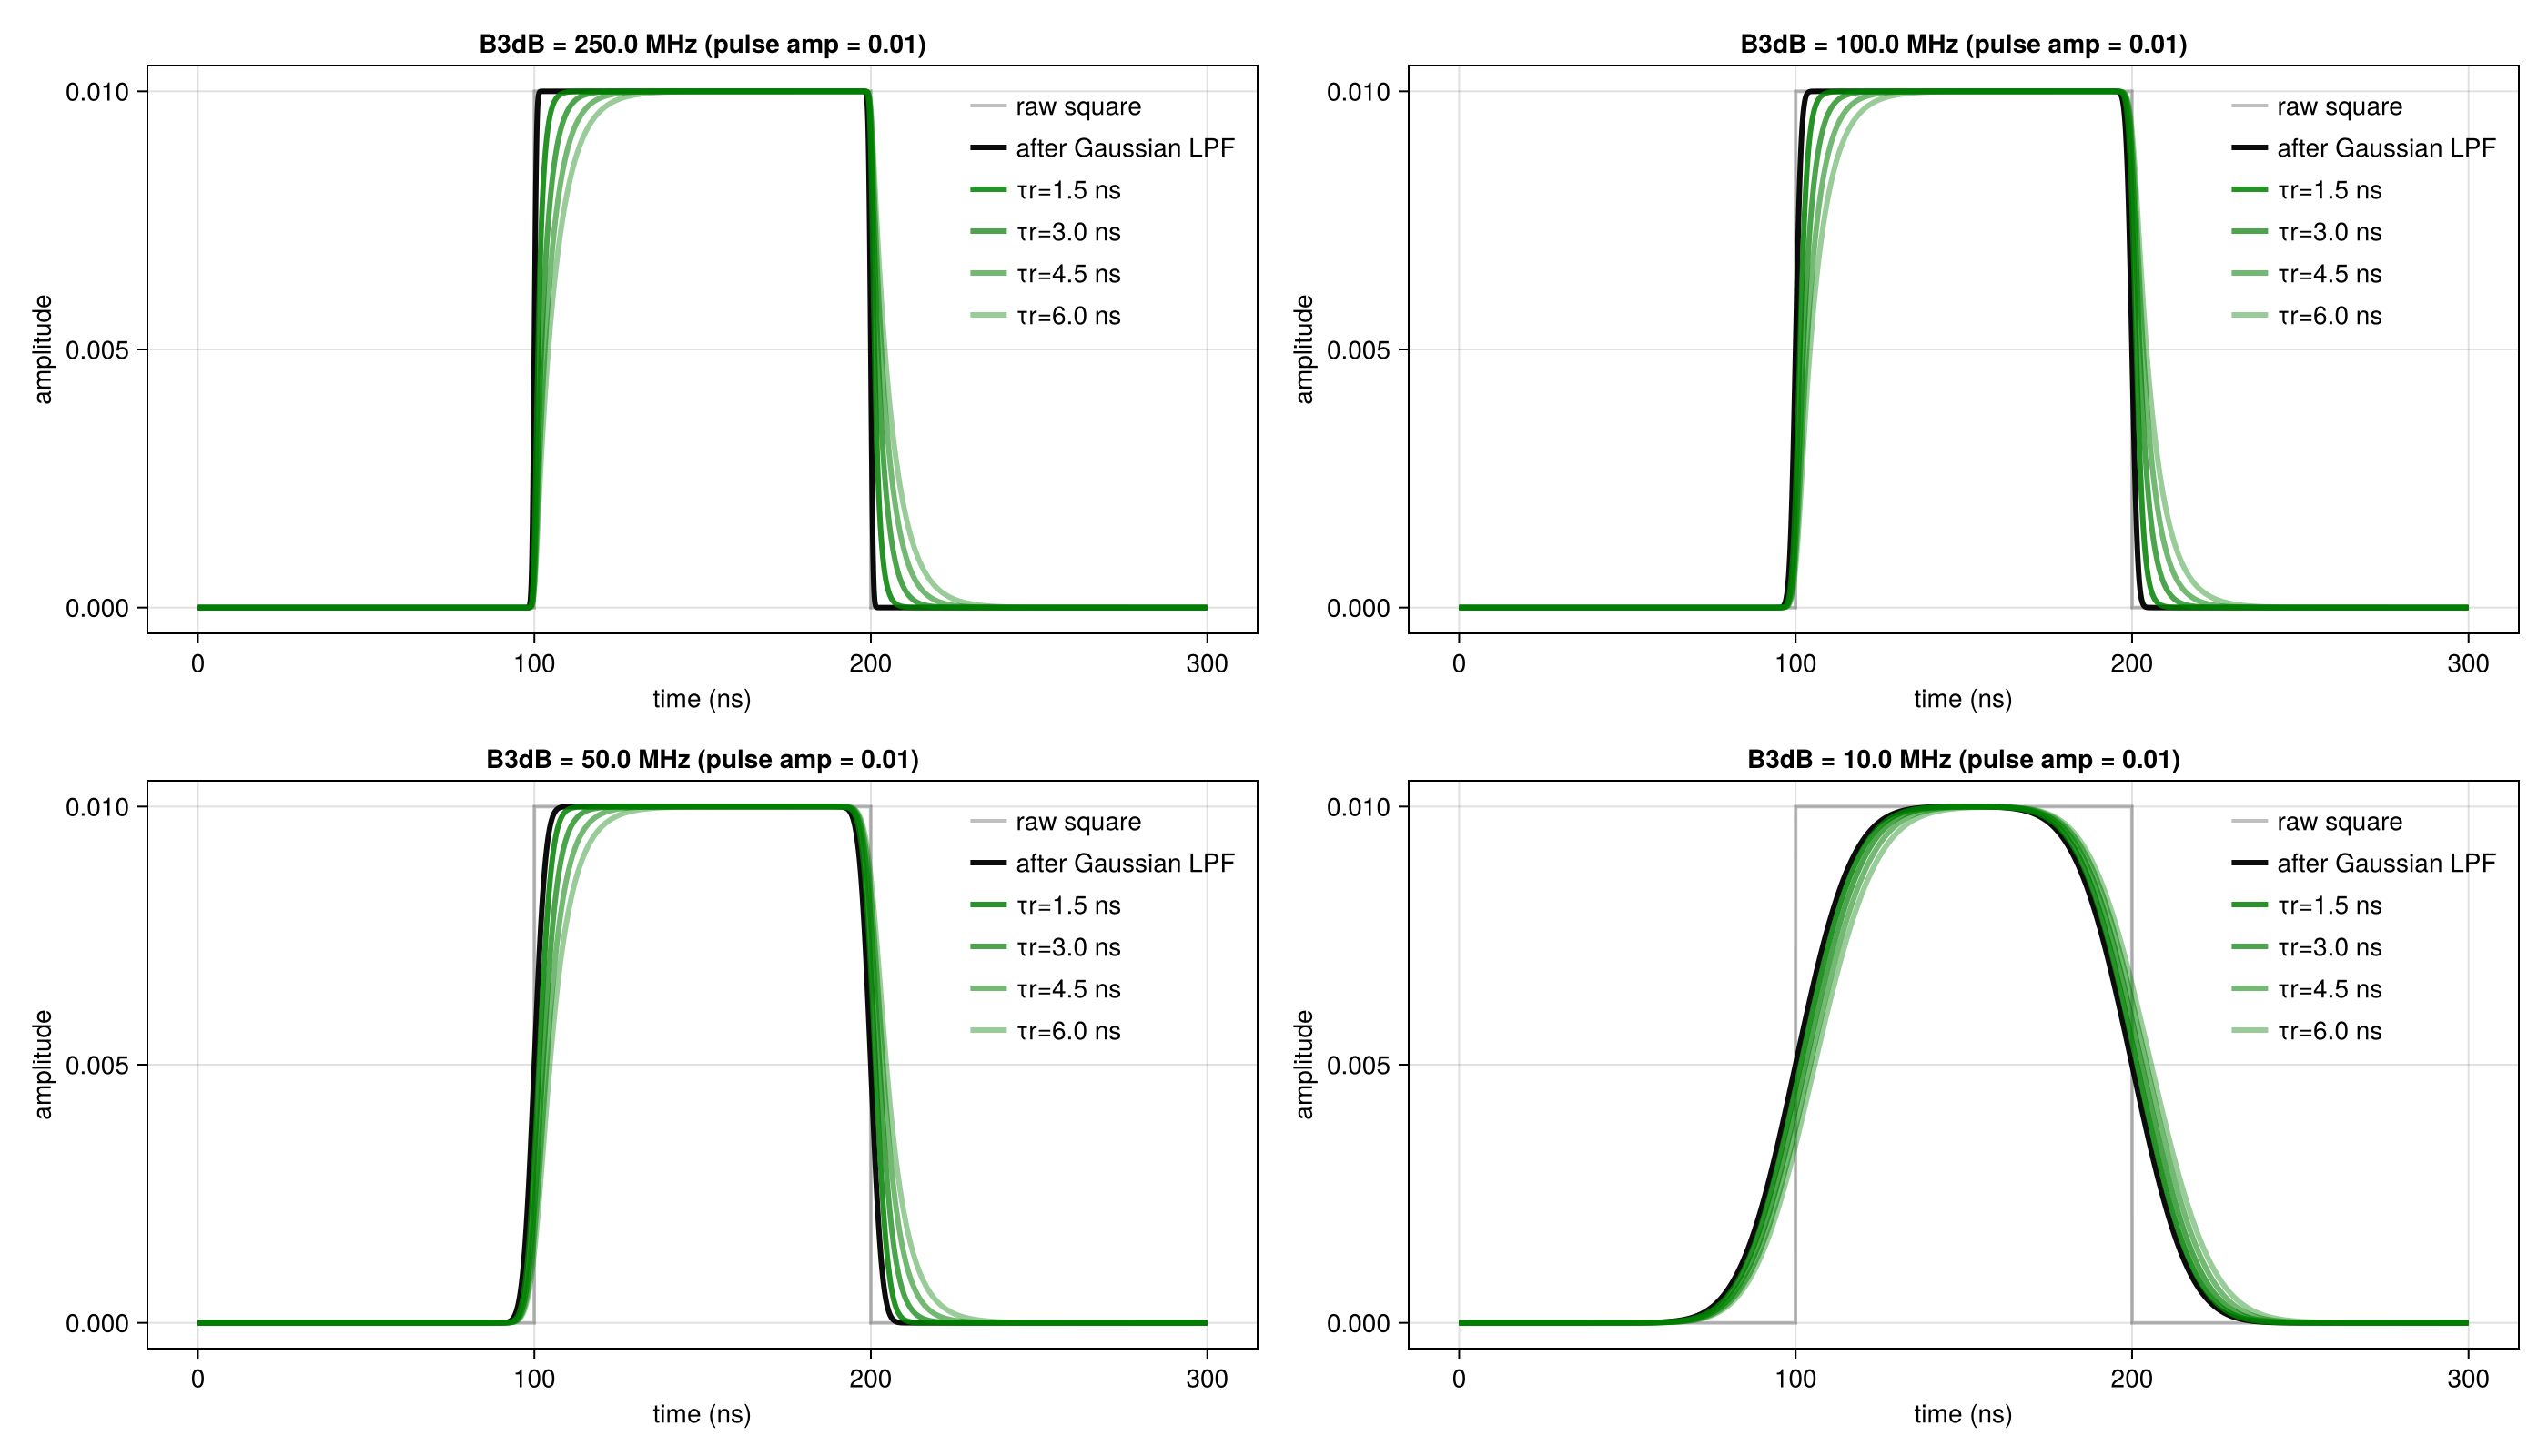

In [1]:
using FFTW
using CairoMakie

# -------------------------
# FFT frequency grid (1/ns) with FFTW ordering
# -------------------------
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# -------------------------
# Build raw square + Gaussian-filtered version (scaled to `amp`)
# -------------------------
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 100.0,
    pre_ns::Float64   = 25.0,
    post_ns::Float64  = 25.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64      = 0.01           # <-- NEW: target amplitude
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square (amplitude = amp)
    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    # Gaussian LPF with -3dB cutoff at B3dB_MHz
    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    # rescale filtered waveform so its max == amp (keeps "pulse amplitude = 0.01")
    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# -------------------------
# Apply exponential distortion in frequency domain
# H(ω) = A / (1 + i ω τr),  ω = 2π f
# (DC gain = A)
# -------------------------
function apply_exp_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end


# ============================================================
# Sweep τr and B3dB, make 4 subplots in one figure
# ============================================================
taus  = [1.5, 3.0, 4.5, 6.0]            # ns
B3dBs = [250.0, 100.0, 50.0, 10.0]       # MHz

# pulse shape settings
width_ns = 100.0
pre_ns   = 100.0
post_ns  = 100.0
dt_ns    = 0.05

A   = 1.0
amp = 0.01                               # <-- pulse amplitude

fig = Figure(size=(1400, 800))

for (p, B3dB_MHz) in enumerate(B3dBs)
    r = (p <= 2) ? 1 : 2
    c = (p == 1 || p == 3) ? 1 : 2

    t_ns, u_sq, u_gf, f_ns = gaussian_filtered_square_ns(
        width_ns = width_ns,
        pre_ns   = pre_ns,
        post_ns  = post_ns,
        dt_ns    = dt_ns,
        B3dB_MHz = B3dB_MHz,
        amp      = amp
    )

    ax = Axis(fig[r, c],
        xlabel="time (ns)",
        ylabel="amplitude",
        title="B3dB = $(B3dB_MHz) MHz (pulse amp = $(amp))"
    )

    # raw square
    lines!(ax, t_ns, u_sq; linewidth=2, color=(:black, 0.25), label="raw square")

    # gaussian-filtered baseline (BLACK)
    lines!(ax, t_ns, u_gf; linewidth=3, color=(:black, 0.95), label="after Gaussian LPF")

    # distortion curves
    for (idx, τr) in enumerate(taus)
        α = 0.85 - 0.15*(idx-1)
        u_dist = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr)
        lines!(ax, t_ns, u_dist; linewidth=3, color=(:green, α), label="τr=$(τr) ns")
    end

    axislegend(ax; position=:rt, framevisible=false)
end

display(fig)
save("distorted_gaussian_square_all_subplots_amp_0p01.png", fig)

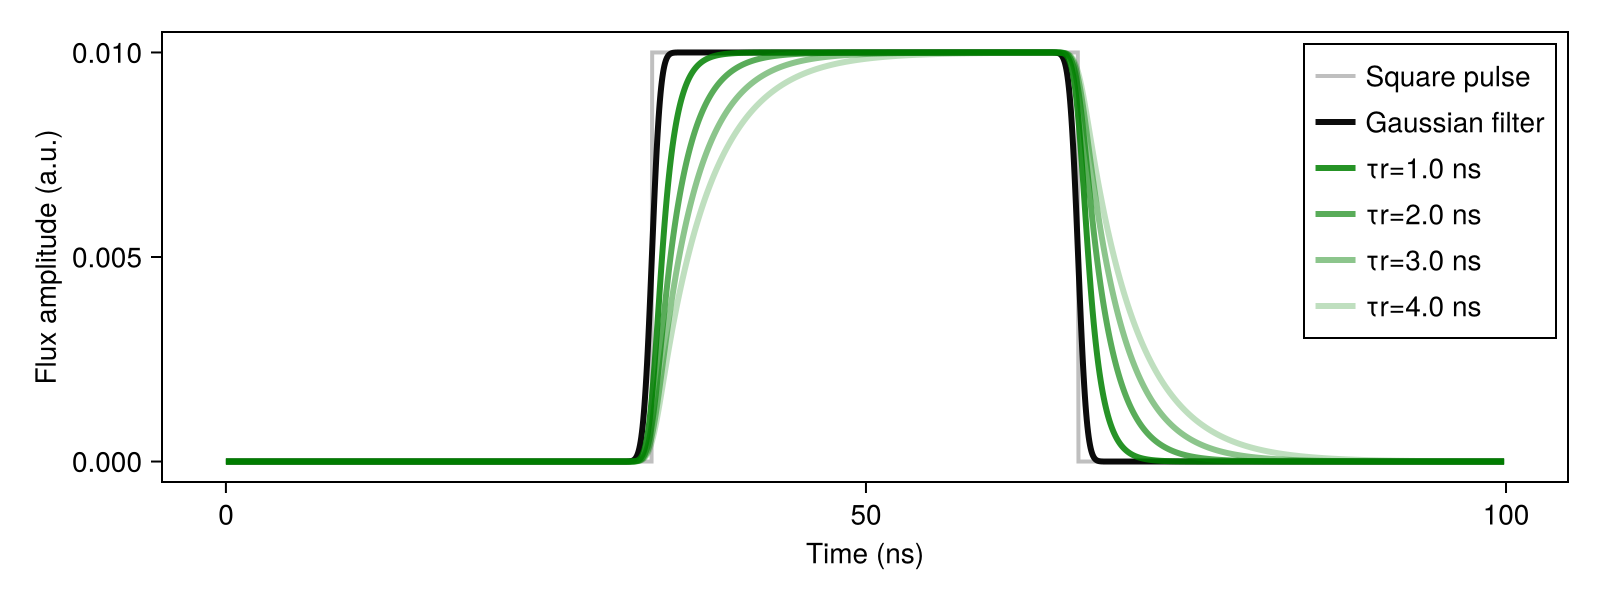

CairoMakie.Screen{PDF}


In [25]:
using FFTW
using CairoMakie

# -------------------------
# FFT frequency grid (1/ns) with FFTW ordering
# -------------------------
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# -------------------------
# Build raw square + Gaussian-filtered version (scaled to `amp`)
# -------------------------
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 50.0,
    pre_ns::Float64   = 25.0,
    post_ns::Float64  = 25.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64      = 0.01
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square (amplitude = amp)
    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    # Gaussian LPF with -3dB cutoff at B3dB_MHz
    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    # rescale filtered waveform so its max == amp
    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# -------------------------
# Apply exponential distortion in frequency domain
# H(ω) = A / (1 + i ω τr),  ω = 2π f
# -------------------------
function apply_exp_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end

# ============================================================
# Single figure for B3dB = 250 MHz
# ============================================================
taus  = [1., 2., 3., 4.]   # ns
B3dB_MHz = 250.0              # <-- fixed

width_ns = 33.3
pre_ns   = 33.3
post_ns  = 33.3
dt_ns    = 0.05

A   = 1.0
amp = 0.01

t_ns, u_sq, u_gf, f_ns = gaussian_filtered_square_ns(
    width_ns = width_ns,
    pre_ns   = pre_ns,
    post_ns  = post_ns,
    dt_ns    = dt_ns,
    B3dB_MHz = B3dB_MHz,
    amp      = amp
)

fig = Figure(size=(800, 300))
ax = Axis(fig[1, 1],
    xlabel = "Time (ns)",
    ylabel = "Flux amplitude (a.u.)",
    #title  = "B3dB = $(B3dB_MHz) MHz (pulse amp = $(amp))"
)

lines!(ax, t_ns, u_sq; linewidth=2, color=(:black, 0.25), label="Square pulse")
lines!(ax, t_ns, u_gf; linewidth=3, color=(:black, 0.95), label="Gaussian filter")

for (idx, τr) in enumerate(taus)
    α = 0.85 - 0.2*(idx-1)
    u_dist = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr)
    lines!(ax, t_ns, u_dist; linewidth=3, color=(:green, α), label="τr=$(τr) ns")
end

axislegend(ax; position=:rt, framevisible=true)

ax.xgridvisible = false
ax.ygridvisible = false

display(fig)
save("distorted.pdf", fig)

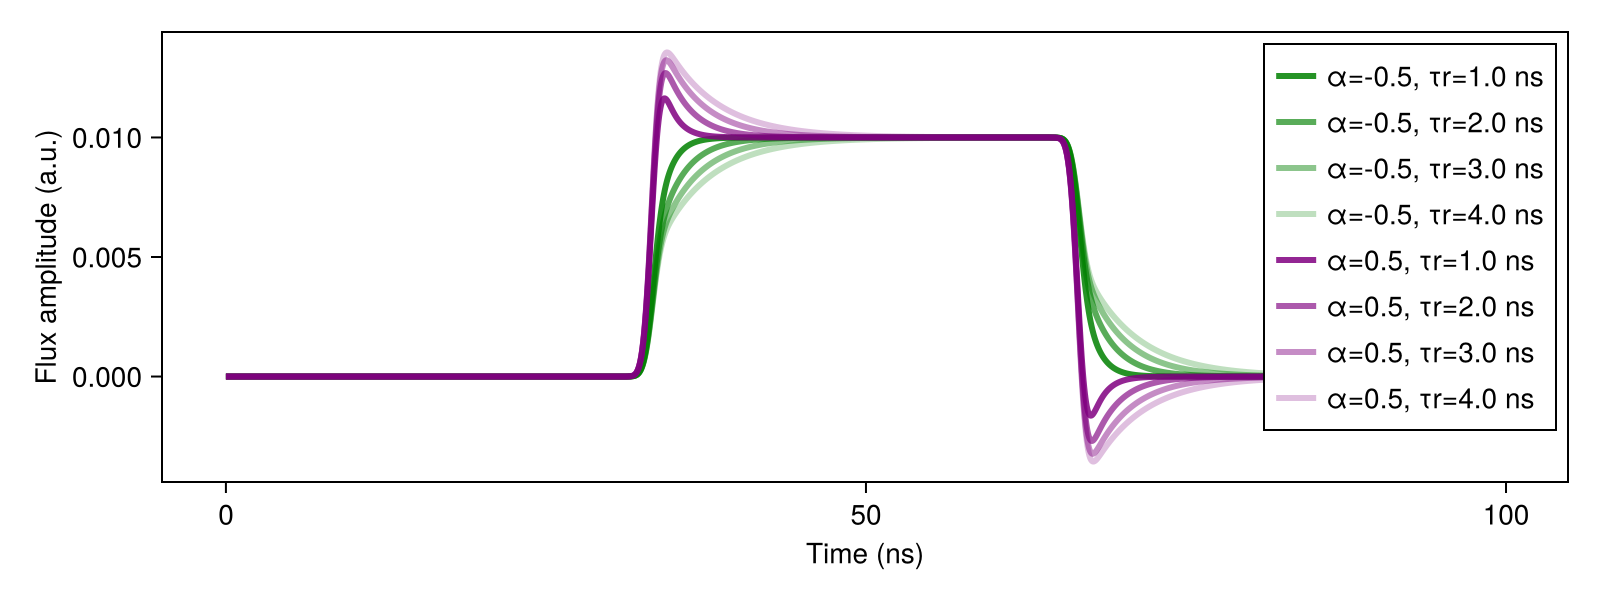

CairoMakie.Screen{IMAGE}


In [ ]:
using FFTW
using CairoMakie

# --- FFT freq grid in 1/ns ---
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# --- Square -> Gaussian LPF (max rescaled to amp) ---
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 50.0,
    pre_ns::Float64   = 25.0,
    post_ns::Float64  = 25.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64      = 0.01
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# ----------------------------------------------------------
# Distortion: H(ω) = 1 + i α ω / (i ω + τ)
# We'll parameterize with τr_ns (time constant), using τ = 1/τr_ns (rate).
# ----------------------------------------------------------
function apply_alpha_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    alpha::Float64 = -1.,
    τr_ns::Float64 = 1.5
)
    ω = 2π .* f_ns                 # rad/ns
    τ_rate = 1.0 / τr_ns           # 1/ns
    H = @. 1 + (1im * alpha * ω) / (1im * ω + τ_rate)
    return real.(ifft(H .* fft(u_in)))
end

# =========================
# Plot (single B3dB = 250)
# =========================
taus  = [1.0, 2.0, 3.0, 4.0]   # ns
alpha = -.5
B3dB_MHz = 250.0

width_ns = 33.3
pre_ns   = 33.3
post_ns  = 33.3
dt_ns    = 0.05
amp      = 0.01

t_ns, u_sq, u_gf, f_ns = gaussian_filtered_square_ns(
    width_ns = width_ns, pre_ns = pre_ns, post_ns = post_ns,
    dt_ns = dt_ns, B3dB_MHz = B3dB_MHz, amp = amp
)

fig = Figure(size=(800, 300))
ax = Axis(fig[1, 1],
    xlabel = "Time (ns)",
    ylabel = "Flux amplitude (a.u.)",
    xgridvisible = false, ygridvisible = false
)

lines!(ax, t_ns, u_sq; linewidth=2, color=(:black, 0.25), label="Square pulse")
lines!(ax, t_ns, u_gf; linewidth=3, color=(:black, 0.95), label="Gaussian filter")

alphas = [-0.5, 0.5]

for αval in alphas
    basecolor = (αval == 0.5) ? :purple : :green

    for (idx, τr) in enumerate(taus)
        αplot = 0.85 - 0.2*(idx-1)
        u_dist = apply_alpha_distortion(u_gf, f_ns; alpha=αval, τr_ns=τr)

        lines!(ax, t_ns, u_dist;
            linewidth=3,
            color=(basecolor, αplot),
            label="α=$(αval), τr=$(τr) ns"
        )
    end
end
axislegend(ax; position=:rt, framevisible=true)

display(fig)
#save("distorted_alpha_0p1.pdf", fig)

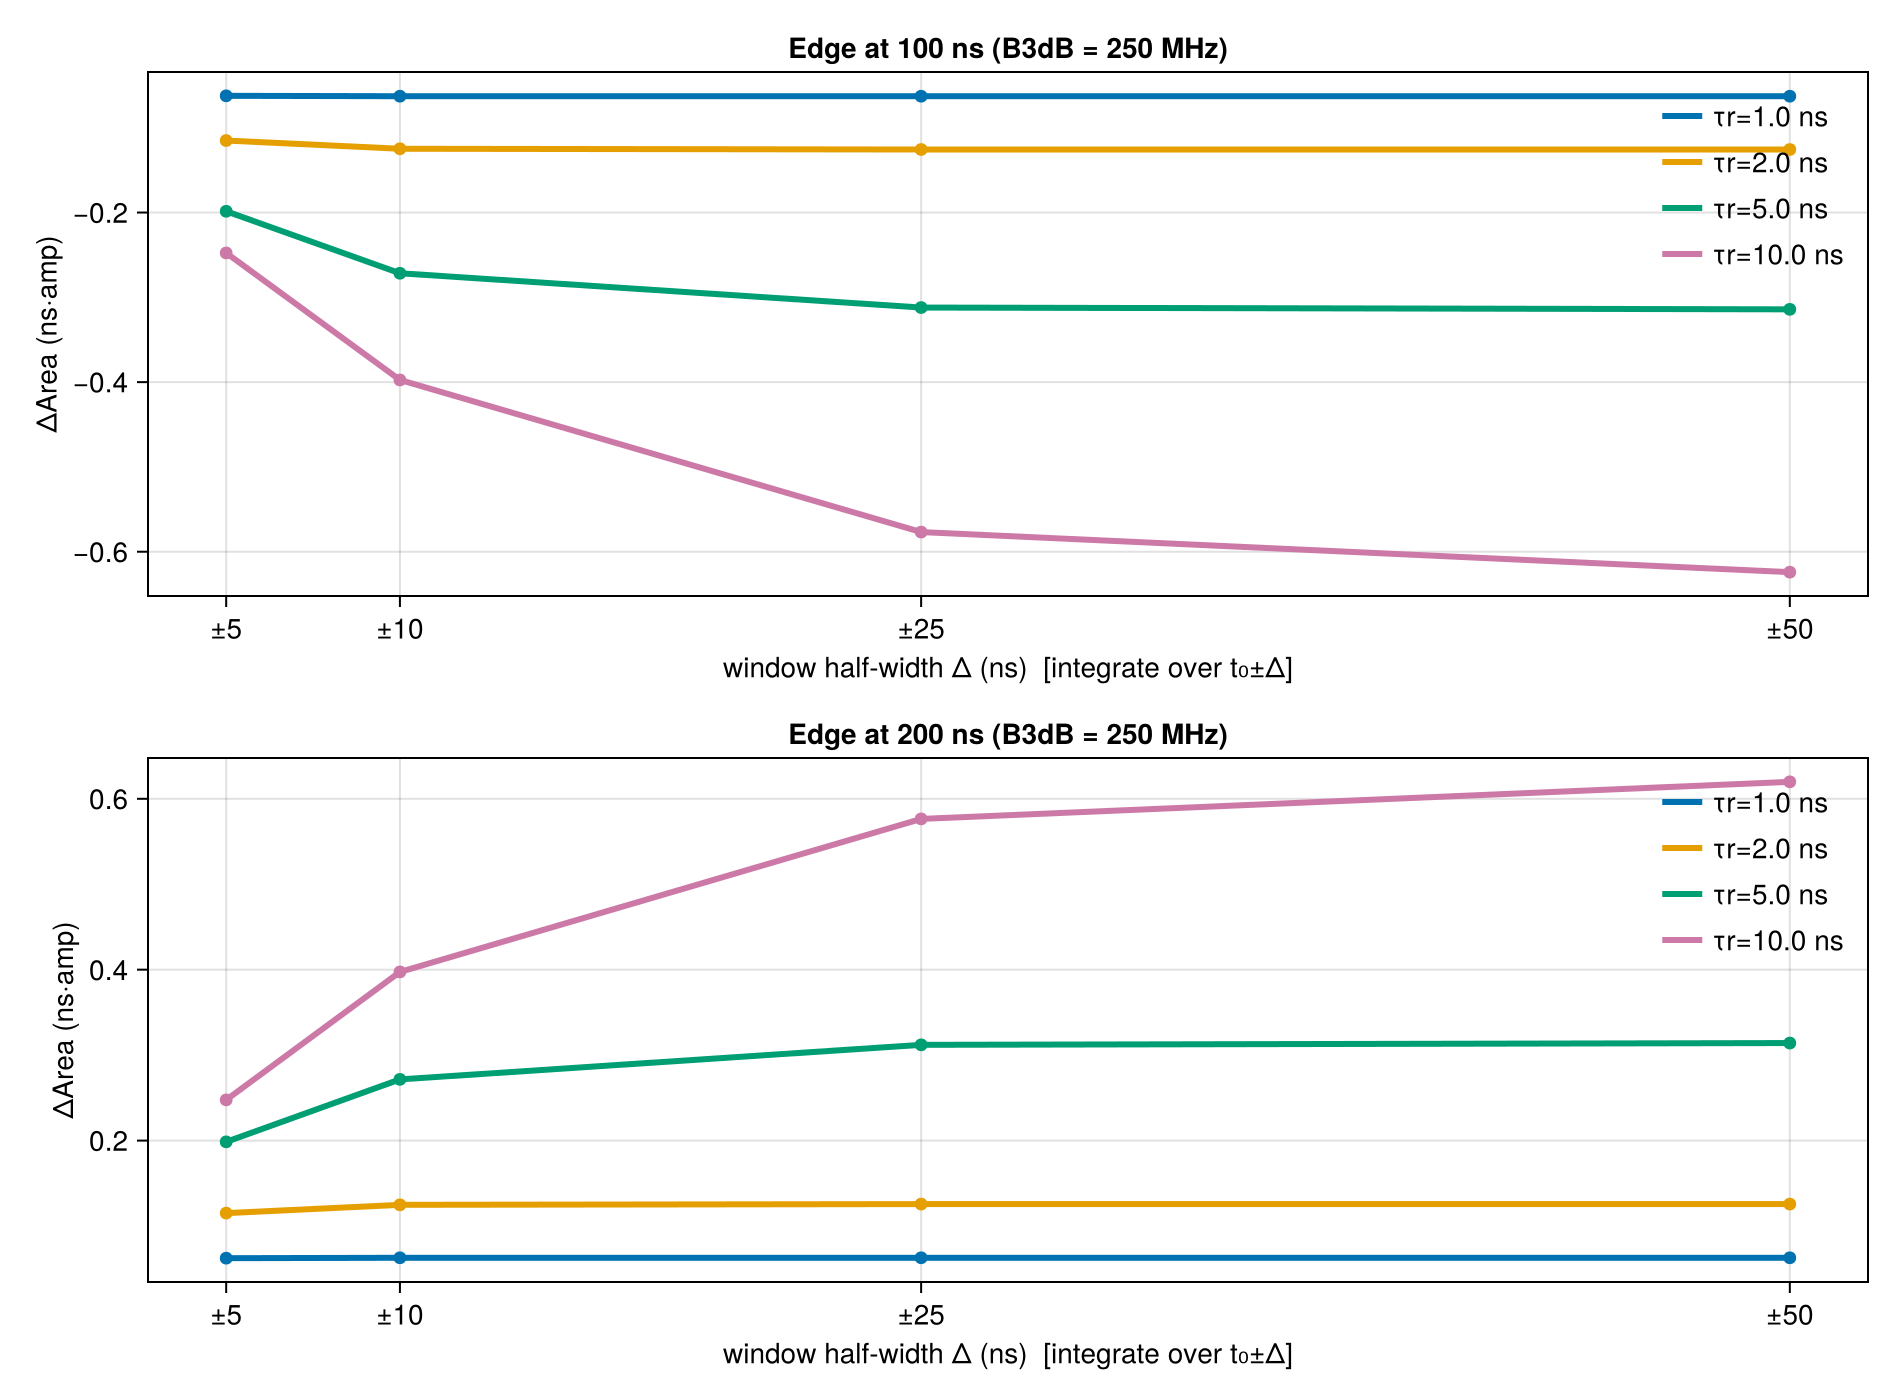

CairoMakie.Screen{IMAGE}


In [6]:
using FFTW
using CairoMakie

# -------------------------
# FFT frequency grid (1/ns) with FFTW ordering
# -------------------------
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# -------------------------
# trapezoid area integral on a window [tL, tR]
# -------------------------
function trapz_area_window(
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Float64,
    tR::Float64
)
    @assert length(t) == length(y)

    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return 0.0
    end

    s = 0.0
    @inbounds for k in 1:length(idx)-1
        i = idx[k]
        j = idx[k+1]
        dt = float(t[j] - t[i])
        s += 0.5 * dt * (float(y[i]) + float(y[j]))
    end
    return s
end

# -------------------------
# Build raw square + Gaussian-filtered version (scaled to `amp`)
# -------------------------
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 100.0,
    pre_ns::Float64   = 100.0,
    post_ns::Float64  = 100.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64      = 0.01
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square (amplitude = amp)
    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    # Gaussian LPF with -3dB cutoff at B3dB_MHz
    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    # rescale filtered waveform so its max == amp
    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# -------------------------
# Apply exponential distortion in frequency domain
# H(ω) = A / (1 + i ω τr),  ω = 2π f
# -------------------------
function apply_exp_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end


# ============================================================
# SETTINGS (ONLY 250 MHz Gaussian filter)
# ============================================================
B3dB_MHz   = 250.0
taus       = [1.0, 2.0, 5.0, 10.0]     # curves
halfwidths = [50.0, 25.0, 10.0, 5.0]         # x-axis values (±Δ)

width_ns = 100.0
pre_ns   = 100.0
post_ns  = 100.0
dt_ns    = 0.05

A   = 1.0
amp = 0.01

t_edge1 = pre_ns               # 100 ns
t_edge2 = pre_ns + width_ns    # 200 ns

# sort x-axis small->big for nicer plotting
Δs = sort(halfwidths)

# ============================================================
# Build baseline once
# ============================================================
t_ns, _, u_gf, f_ns = gaussian_filtered_square_ns(
    width_ns = width_ns,
    pre_ns   = pre_ns,
    post_ns  = post_ns,
    dt_ns    = dt_ns,
    B3dB_MHz = B3dB_MHz,
    amp      = amp
)

# ============================================================
# Compute ΔArea as a function of Δ (x-axis), for each τr (curve)
# ============================================================
# results_edge1[τr] = vector over Δs
# results_edge2[τr] = vector over Δs
results_edge1 = Dict{Float64, Vector{Float64}}()
results_edge2 = Dict{Float64, Vector{Float64}}()

for τr in taus
    u_dist = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr)

    y1 = Float64[]
    y2 = Float64[]

    for Δ in Δs
        # baseline areas
        Agf_1 = trapz_area_window(t_ns, u_gf, t_edge1-Δ, t_edge1+Δ)
        Agf_2 = trapz_area_window(t_ns, u_gf, t_edge2-Δ, t_edge2+Δ)

        # distorted areas
        Ad_1 = trapz_area_window(t_ns, u_dist, t_edge1-Δ, t_edge1+Δ)
        Ad_2 = trapz_area_window(t_ns, u_dist, t_edge2-Δ, t_edge2+Δ)

        push!(y1, Ad_1 - Agf_1)
        push!(y2, Ad_2 - Agf_2)
    end

    results_edge1[τr] = y1
    results_edge2[τr] = y2
end


# ============================================================
# Plot: X axis = ± window size Δ, curves = τr
# ============================================================
fig = Figure(size=(950, 700))

ax1 = Axis(fig[1,1],
    xlabel="window half-width Δ (ns)  [integrate over t₀±Δ]",
    ylabel="ΔArea (ns·amp)",
    title="Edge at 100 ns (B3dB = 250 MHz)"
)

ax2 = Axis(fig[2,1],
    xlabel="window half-width Δ (ns)  [integrate over t₀±Δ]",
    ylabel="ΔArea (ns·amp)",
    title="Edge at 200 ns (B3dB = 250 MHz)"
)

for τr in taus
    y1 = results_edge1[τr]
    y2 = results_edge2[τr]

    lines!(ax1, Δs, y1 .* 2 * pi; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax1, Δs, y1 .* 2 * pi; markersize=9)

    lines!(ax2, Δs, y2 .* 2 * pi; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax2, Δs, y2 .* 2 * pi; markersize=9)
end

# nicer tick labels: show as "±5", "±10", "±25"
ax1.xticks = (Δs, ["±$(Int(Δ))" for Δ in Δs])
ax2.xticks = (Δs, ["±$(Int(Δ))" for Δ in Δs])

axislegend(ax1; position=:rt, framevisible=false)
axislegend(ax2; position=:rt, framevisible=false)

display(fig)
#save("delta_area_vs_window_size_only_B3dB250.png", fig)

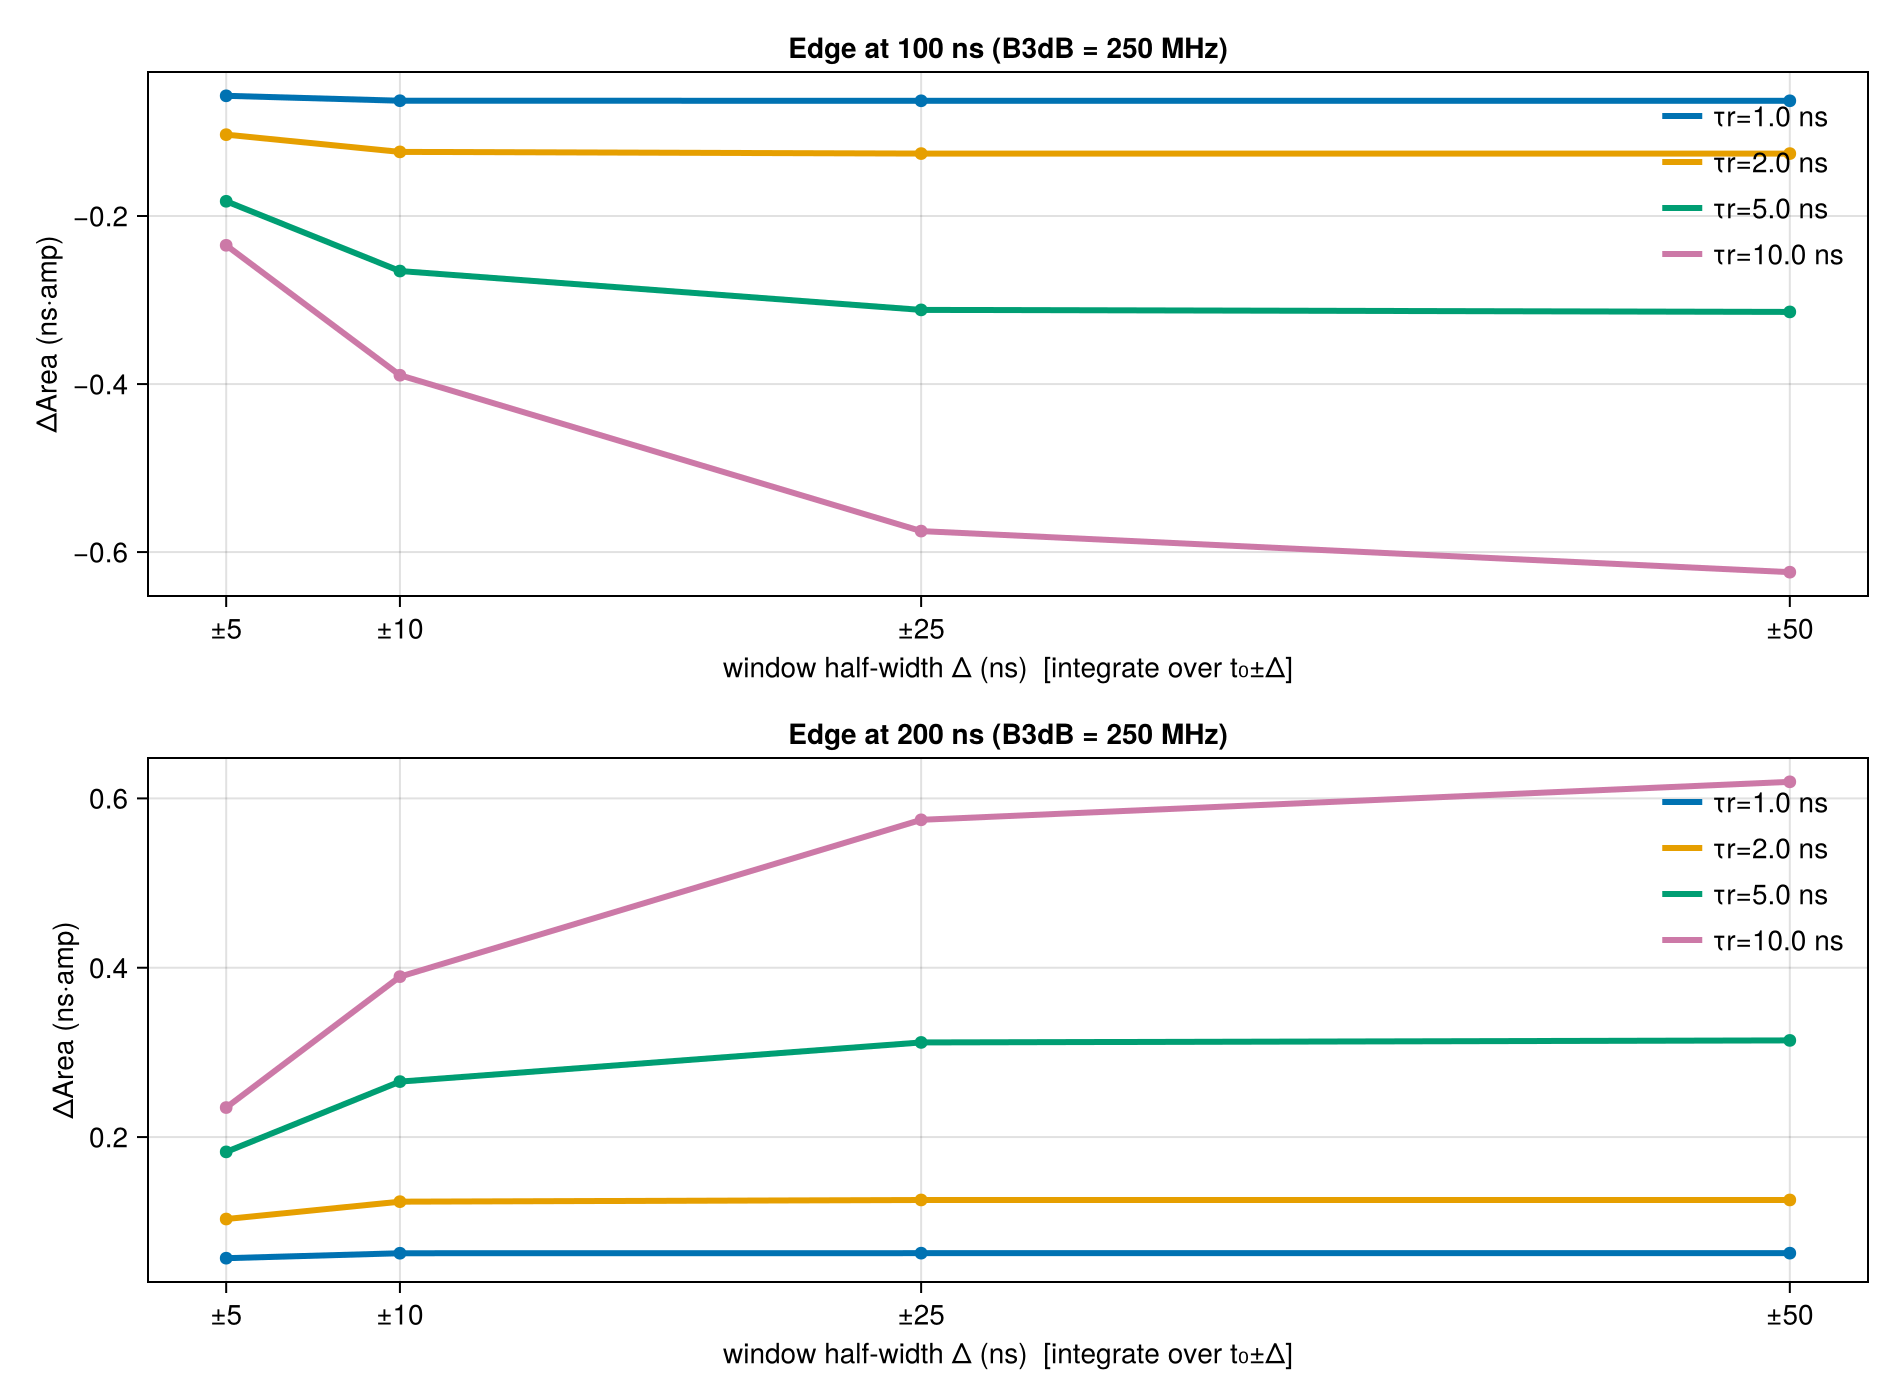

CairoMakie.Screen{IMAGE}


In [7]:
using FFTW
using CairoMakie

# -------------------------
# FFT frequency grid (1/ns) with FFTW ordering
# -------------------------
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# -------------------------
# trapezoid area integral on a window [tL, tR]
# -------------------------
function trapz_area_window(
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Float64,
    tR::Float64
)
    @assert length(t) == length(y)

    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return 0.0
    end

    s = 0.0
    @inbounds for k in 1:length(idx)-1
        i = idx[k]
        j = idx[k+1]
        dt = float(t[j] - t[i])
        s += 0.5 * dt * (float(y[i]) + float(y[j]))
    end
    return s
end

# -------------------------
# Build raw square + Gaussian-filtered version (scaled to `amp`)
# -------------------------
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 100.0,
    pre_ns::Float64   = 100.0,
    post_ns::Float64  = 100.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    amp::Float64      = 0.01
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square (amplitude = amp)
    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    # Gaussian LPF with -3dB cutoff at B3dB_MHz
    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    # rescale filtered waveform so its max == amp
    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# -------------------------
# Apply exponential distortion in frequency domain
# H(ω) = A / (1 + i ω τr),  ω = 2π f
# -------------------------
function apply_exp_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end


# ============================================================
# SETTINGS (ONLY 250 MHz Gaussian filter)
# ============================================================
B3dB_MHz   = 50.0
taus       = [1.0, 2.0, 5.0, 10.0]     # curves
halfwidths = [50.0, 25.0, 10.0, 5.0]         # x-axis values (±Δ)

width_ns = 100.0
pre_ns   = 100.0
post_ns  = 100.0
dt_ns    = 0.05

A   = 1.0
amp = 0.01

t_edge1 = pre_ns               # 100 ns
t_edge2 = pre_ns + width_ns    # 200 ns

# sort x-axis small->big for nicer plotting
Δs = sort(halfwidths)

# ============================================================
# Build baseline once
# ============================================================
t_ns, _, u_gf, f_ns = gaussian_filtered_square_ns(
    width_ns = width_ns,
    pre_ns   = pre_ns,
    post_ns  = post_ns,
    dt_ns    = dt_ns,
    B3dB_MHz = B3dB_MHz,
    amp      = amp
)

# ============================================================
# Compute ΔArea as a function of Δ (x-axis), for each τr (curve)
# ============================================================
# results_edge1[τr] = vector over Δs
# results_edge2[τr] = vector over Δs
results_edge1 = Dict{Float64, Vector{Float64}}()
results_edge2 = Dict{Float64, Vector{Float64}}()

for τr in taus
    u_dist = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr)

    y1 = Float64[]
    y2 = Float64[]

    for Δ in Δs
        # baseline areas
        Agf_1 = trapz_area_window(t_ns, u_gf, t_edge1-Δ, t_edge1+Δ)
        Agf_2 = trapz_area_window(t_ns, u_gf, t_edge2-Δ, t_edge2+Δ)

        # distorted areas
        Ad_1 = trapz_area_window(t_ns, u_dist, t_edge1-Δ, t_edge1+Δ)
        Ad_2 = trapz_area_window(t_ns, u_dist, t_edge2-Δ, t_edge2+Δ)

        push!(y1, Ad_1 - Agf_1)
        push!(y2, Ad_2 - Agf_2)
    end

    results_edge1[τr] = y1
    results_edge2[τr] = y2
end


# ============================================================
# Plot: X axis = ± window size Δ, curves = τr
# ============================================================
fig = Figure(size=(950, 700))

ax1 = Axis(fig[1,1],
    xlabel="window half-width Δ (ns)  [integrate over t₀±Δ]",
    ylabel="ΔArea (ns·amp)",
    title="Edge at 100 ns (B3dB = 250 MHz)"
)

ax2 = Axis(fig[2,1],
    xlabel="window half-width Δ (ns)  [integrate over t₀±Δ]",
    ylabel="ΔArea (ns·amp)",
    title="Edge at 200 ns (B3dB = 250 MHz)"
)

for τr in taus
    y1 = results_edge1[τr]
    y2 = results_edge2[τr]

    lines!(ax1, Δs, y1 .* 2 * pi; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax1, Δs, y1 .* 2 * pi; markersize=9)

    lines!(ax2, Δs, y2 .* 2 * pi; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax2, Δs, y2 .* 2 * pi; markersize=9)
end

# nicer tick labels: show as "±5", "±10", "±25"
ax1.xticks = (Δs, ["±$(Int(Δ))" for Δ in Δs])
ax2.xticks = (Δs, ["±$(Int(Δ))" for Δ in Δs])

axislegend(ax1; position=:rt, framevisible=false)
axislegend(ax2; position=:rt, framevisible=false)

display(fig)
#save("delta_area_vs_window_size_only_B3dB250.png", fig)

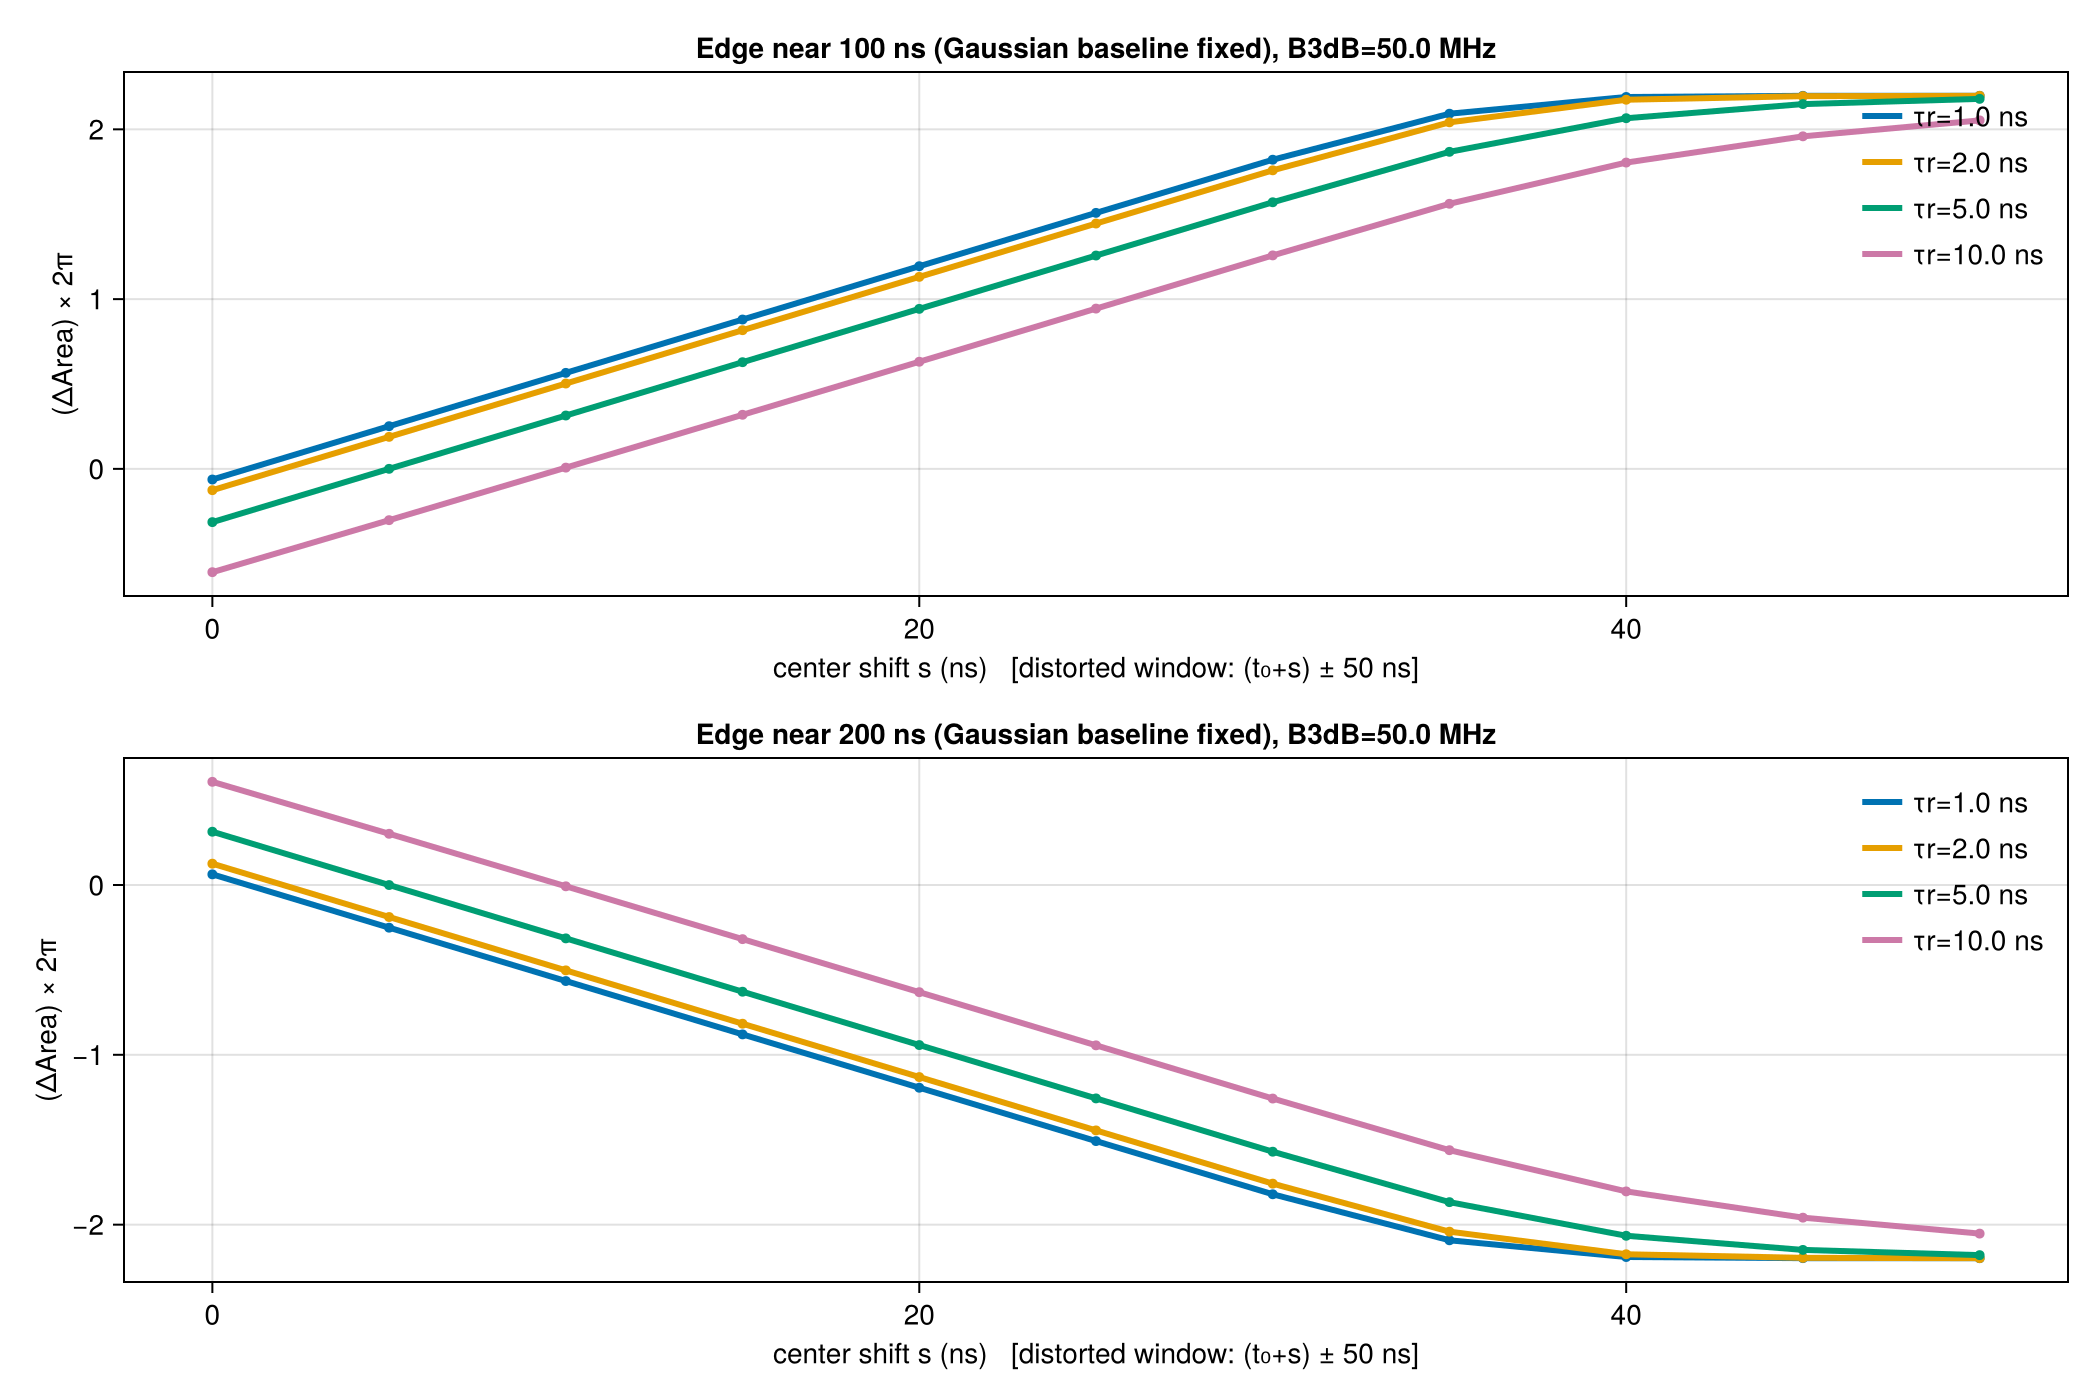

CairoMakie.Screen{IMAGE}


In [8]:
using FFTW
using CairoMakie

# -------------------------
# FFT frequency grid (1/ns) with FFTW ordering
# -------------------------
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # 1/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# -------------------------
# trapezoid area integral on a window [tL, tR]
# -------------------------
function trapz_area_window(
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Float64,
    tR::Float64
)
    @assert length(t) == length(y)

    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return 0.0
    end

    s = 0.0
    @inbounds for k in 1:length(idx)-1
        i = idx[k]
        j = idx[k+1]
        dt = float(t[j] - t[i])
        s += 0.5 * dt * (float(y[i]) + float(y[j]))
    end
    return s
end

# -------------------------
# Build raw square + Gaussian-filtered version (scaled to `amp`)
# -------------------------
function gaussian_filtered_square_ns(;
    width_ns::Float64 = 100.0,
    pre_ns::Float64   = 100.0,
    post_ns::Float64  = 100.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 50.0,
    amp::Float64      = 0.01
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square (amplitude = amp)
    u_raw = zeros(Float64, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    u_raw[i0:i1] .= amp

    f_ns = fftfreq_ns(N, dt_ns)

    # Gaussian LPF with -3dB cutoff at B3dB_MHz
    B3dB_ns = B3dB_MHz / 1000.0
    σ = B3dB_ns / sqrt(log(2.0))
    G = @. exp(-0.5 * (f_ns^2) / σ^2)

    u_gf = real.(ifft(G .* fft(u_raw)))

    # rescale filtered waveform so its max == amp
    mx = maximum(u_gf)
    if mx > 0
        u_gf .*= (amp / mx)
    end

    return t_ns, u_raw, u_gf, f_ns
end

# -------------------------
# Apply exponential distortion in frequency domain
# H(ω) = A / (1 + i ω τr),  ω = 2π f
# -------------------------
function apply_exp_distortion(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.0,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end


# ============================================================
# SETTINGS
# ============================================================
B3dB_MHz = 50.0
taus     = [1.0, 2.0, 5.0, 10.0]     # curves

Δ        = 35.0                      # <-- fixed half-width (±50ns)
shifts   = collect(0.0:5.0:50.0)   # x-axis shifts (ns)

width_ns = 100.0
pre_ns   = 100.0
post_ns  = 100.0
dt_ns    = 0.05

A   = 1.0
amp = 0.01

t_edge1 = pre_ns               # 100 ns
t_edge2 = pre_ns + width_ns    # 200 ns

# ============================================================
# Build baseline pulse once
# ============================================================
t_ns, _, u_gf, f_ns = gaussian_filtered_square_ns(
    width_ns = width_ns,
    pre_ns   = pre_ns,
    post_ns  = post_ns,
    dt_ns    = dt_ns,
    B3dB_MHz = B3dB_MHz,
    amp      = amp
)

# ============================================================
# FIXED Gaussian baseline areas (DO NOT SHIFT)
# ============================================================
Agf_1_fixed = trapz_area_window(t_ns, u_gf, t_edge1-Δ, t_edge1+Δ)
Agf_2_fixed = trapz_area_window(t_ns, u_gf, t_edge2-Δ, t_edge2+Δ)

# ============================================================
# Compute ΔArea(s) = Adist(center+s) - Agf(center)
# (only Adist window moves)
# ============================================================
results_edge1 = Dict{Float64, Vector{Float64}}()
results_edge2 = Dict{Float64, Vector{Float64}}()

for τr in taus
    u_dist = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr)

    y1 = Float64[]
    y2 = Float64[]

    for s in shifts
        # shifted distorted centers ONLY
        c1 = t_edge1 + s
        c2 = t_edge2 + s

        Ad_1 = trapz_area_window(t_ns, u_dist, c1-Δ, c1+Δ)
        Ad_2 = trapz_area_window(t_ns, u_dist, c2-Δ, c2+Δ)

        push!(y1, (Ad_1 - Agf_1_fixed) * 2π)
        push!(y2, (Ad_2 - Agf_2_fixed) * 2π)
    end

    results_edge1[τr] = y1
    results_edge2[τr] = y2
end


# ============================================================
# Plot: x = shift, y = ΔArea*2π
# ============================================================
fig = Figure(size=(1050, 700))

ax1 = Axis(fig[1,1],
    xlabel="center shift s (ns)   [distorted window: (t₀+s) ± 50 ns]",
    ylabel="(ΔArea) × 2π",
    title="Edge near 100 ns (Gaussian baseline fixed), B3dB=$(B3dB_MHz) MHz"
)

ax2 = Axis(fig[2,1],
    xlabel="center shift s (ns)   [distorted window: (t₀+s) ± 50 ns]",
    ylabel="(ΔArea) × 2π",
    title="Edge near 200 ns (Gaussian baseline fixed), B3dB=$(B3dB_MHz) MHz"
)

for τr in taus
    lines!(ax1, shifts, results_edge1[τr]; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax1, shifts, results_edge1[τr]; markersize=7)

    lines!(ax2, shifts, results_edge2[τr]; linewidth=3, label="τr=$(τr) ns")
    scatter!(ax2, shifts, results_edge2[τr]; markersize=7)
end

axislegend(ax1; position=:rt, framevisible=false)
axislegend(ax2; position=:rt, framevisible=false)

display(fig)
#save("delta_area_vs_center_shift_ONLY_distorted_moves_B3dB_$(Int(round(B3dB_MHz)))MHz.png", fig)

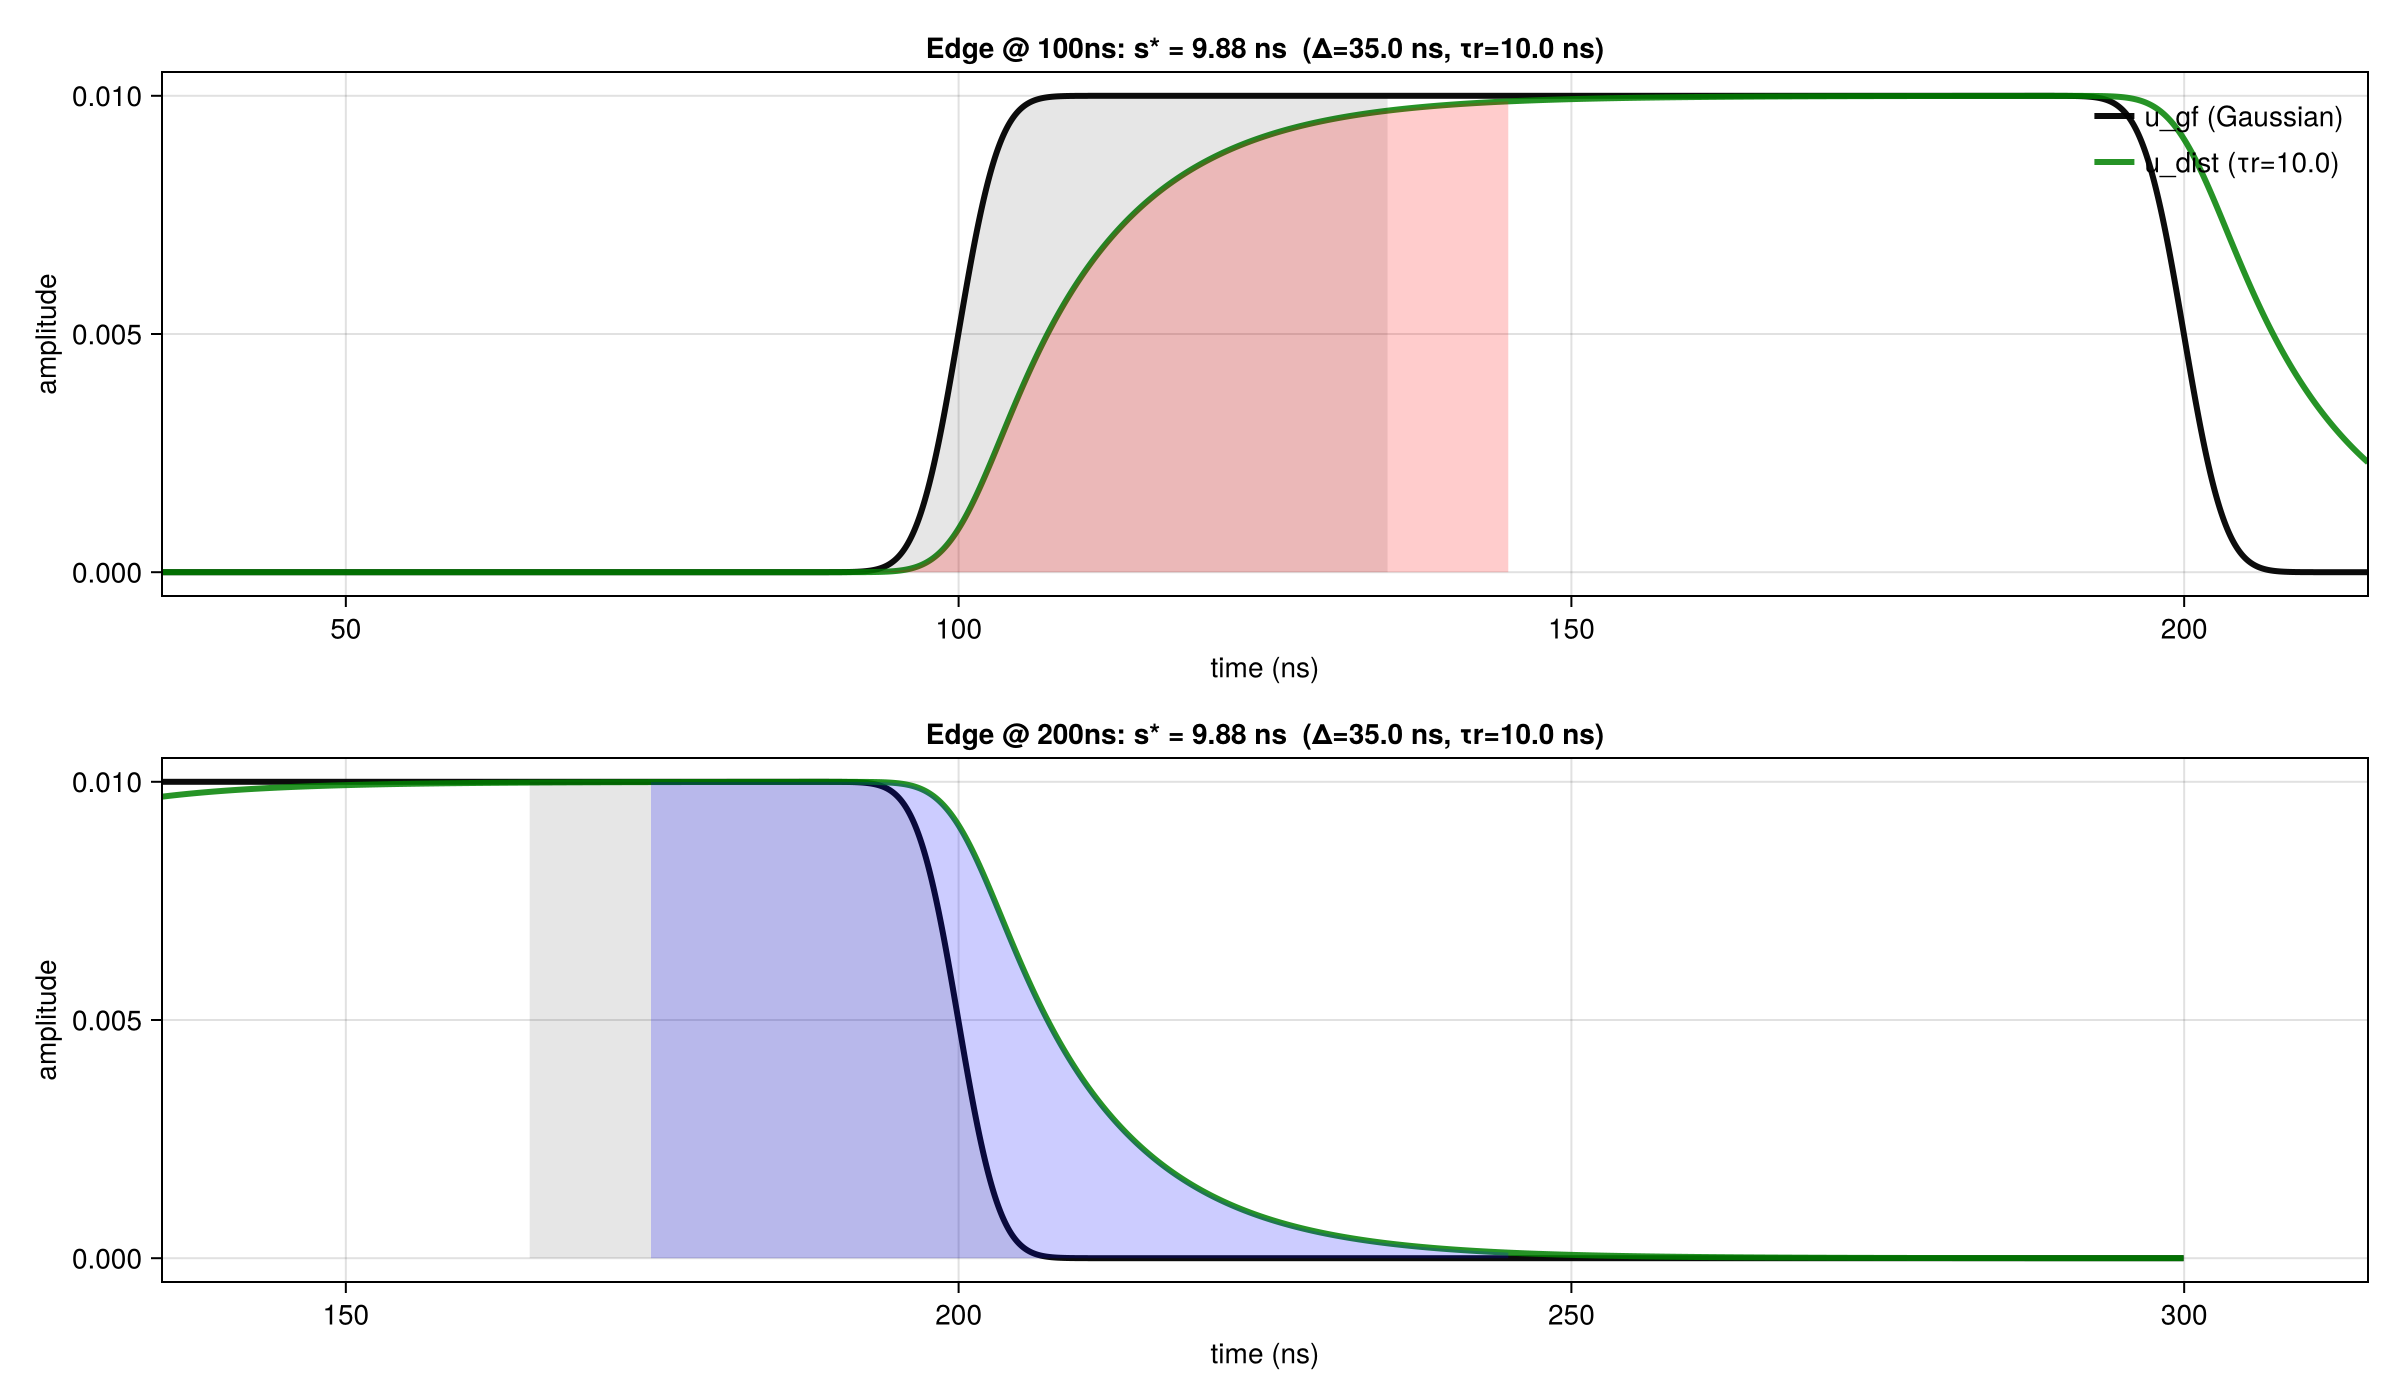


================ SHIFT FOR ZERO AREA DIFFERENCE ================
Using τr = 10.0 ns, Δ = 35.0 ns, B3dB = 50.0 MHz
Edge 100ns: s* = 9.883491750495974 ns   (method = interp)
Edge 200ns: s* = 9.877604686246087 ns   (method = interp)
NOTE: If method=:closest, extend shifts (e.g. -50:5:50) to bracket a root.



CairoMakie.Screen{IMAGE}


In [9]:
# ============================================================
# Find shift s* such that ΔA(s)=0, then shade UNDER CURVE areas
# ============================================================

# ---- helper: shade area under y(t) over [tL,tR] down to baseline=0 ----
function shade_under_curve!(
    ax,
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Float64,
    tR::Float64;
    color = (:red, 0.18)
)
    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return
    end

    tw = Float64.(t[idx])
    yw = Float64.(y[idx])

    # polygon points: (tw, yw) then (reverse(tw), 0)
    xs = vcat(tw, reverse(tw))
    ys = vcat(yw, zeros(length(yw)))

    poly!(ax, xs, ys; color=color, strokewidth=0)
end

# ---- helper: find s* where f(s)=0 using sign-change + linear interp ----
function find_root_shift(shifts::AbstractVector{<:Real}, fvals::AbstractVector{<:Real})
    s = Float64.(shifts)
    f = Float64.(fvals)

    # search for sign change
    for k in 1:length(s)-1
        f0, f1 = f[k], f[k+1]
        if f0 == 0
            return s[k], :exact
        end
        if f0 * f1 < 0
            # linear interpolation root
            s0, s1 = s[k], s[k+1]
            s_star = s0 + (0 - f0) * (s1 - s0) / (f1 - f0)
            return s_star, :interp
        end
    end

    # no sign change => return closest-to-zero value (best approx)
    kbest = argmin(abs.(f))
    return s[kbest], :closest
end

# ============================================================
# Largest distortion
# ============================================================
τr_max = maximum(taus)
u_dist_max = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr_max)

# NOTE:
# results_edge1/2 already store y = (Ad - Agf_fixed)*2π
ΔA1 = results_edge1[τr_max]
ΔA2 = results_edge2[τr_max]

# Find s* separately for edge 100 and edge 200
s1_star, how1 = find_root_shift(shifts, ΔA1)
s2_star, how2 = find_root_shift(shifts, ΔA2)

println("\n================ SHIFT FOR ZERO AREA DIFFERENCE ================")
println("Using τr = $τr_max ns, Δ = $Δ ns, B3dB = $B3dB_MHz MHz")
println("Edge 100ns: s* = $s1_star ns   (method = $how1)")
println("Edge 200ns: s* = $s2_star ns   (method = $how2)")
println("NOTE: If method=:closest, extend shifts (e.g. -50:5:50) to bracket a root.")
println("===============================================================\n")

# ============================================================
# Plot time domain + shade UNDER CURVE
# ============================================================
figZ = Figure(size=(1200, 700))

ax1 = Axis(figZ[1,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="Edge @ 100ns: s* = $(round(s1_star, digits=2)) ns  (Δ=$(Δ) ns, τr=$(τr_max) ns)"
)

ax2 = Axis(figZ[2,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="Edge @ 200ns: s* = $(round(s2_star, digits=2)) ns  (Δ=$(Δ) ns, τr=$(τr_max) ns)"
)

# ---- plot curves on both axes ----
for ax in (ax1, ax2)
    lines!(ax, t_ns, u_gf;       linewidth=3, color=(:black, 0.95), label="u_gf (Gaussian)")
    lines!(ax, t_ns, u_dist_max; linewidth=3, color=(:green, 0.85), label="u_dist (τr=$τr_max)")
end

# ---- Edge 100 ----
c_fixed_1 = t_edge1                     # 100
c_shift_1 = t_edge1 + s1_star

# shade fixed Gaussian window under u_gf
shade_under_curve!(ax1, t_ns, u_gf, c_fixed_1-Δ, c_fixed_1+Δ; color=(:black, 0.10))
# shade shifted distorted window under u_dist
shade_under_curve!(ax1, t_ns, u_dist_max, c_shift_1-Δ, c_shift_1+Δ; color=(:red, 0.20))

# ---- Edge 200 ----
c_fixed_2 = t_edge2                     # 200
c_shift_2 = t_edge2 + s2_star

shade_under_curve!(ax2, t_ns, u_gf, c_fixed_2-Δ, c_fixed_2+Δ; color=(:black, 0.10))
shade_under_curve!(ax2, t_ns, u_dist_max, c_shift_2-Δ, c_shift_2+Δ; color=(:blue, 0.20))

axislegend(ax1; position=:rt, framevisible=false)

# zoom xlims so you actually SEE the shaded windows
xlims!(ax1, (t_edge1 - Δ) - 30, (t_edge1 + maximum(shifts) + Δ) + 30)
xlims!(ax2, (t_edge2 - Δ) - 30, (t_edge2 + maximum(shifts) + Δ) + 30)

display(figZ)
# save("zero_area_shift_shaded_under_curve.png", figZ)

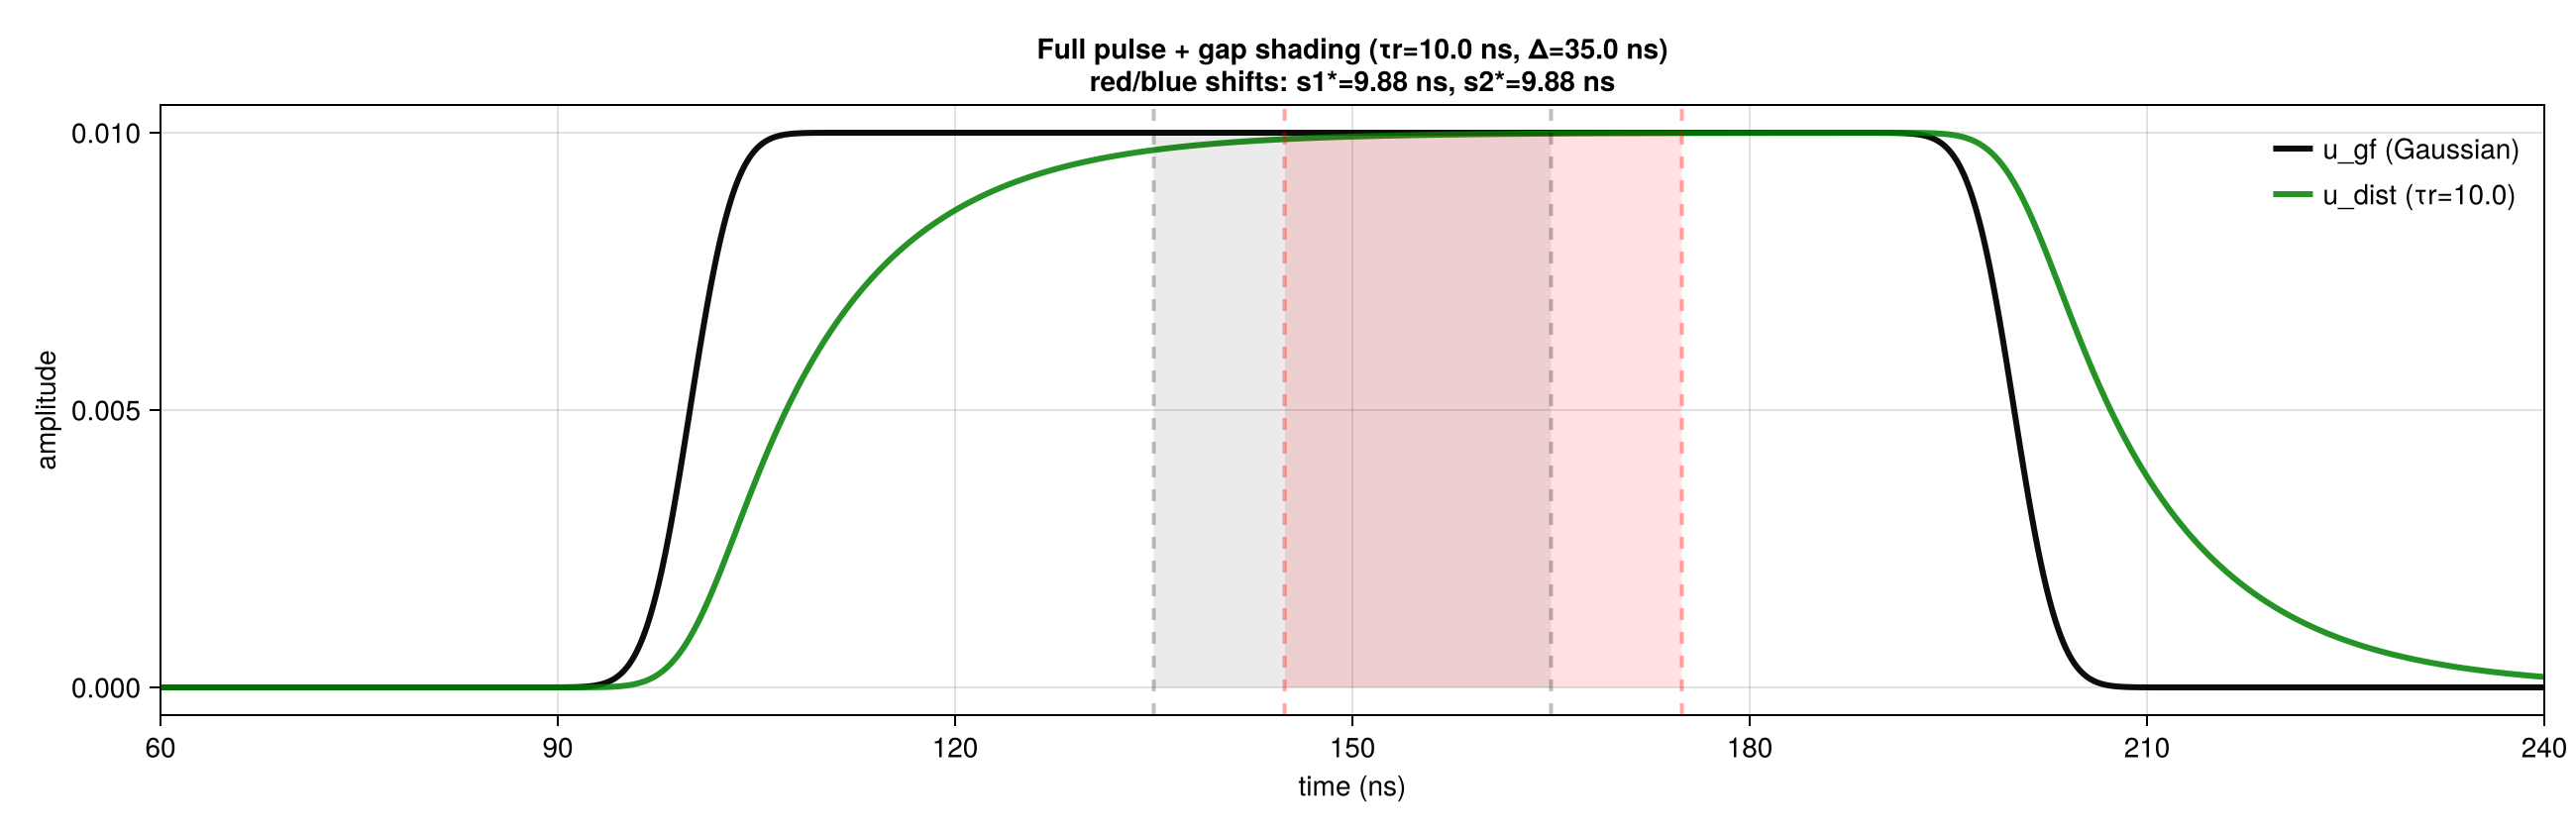


================ GAP WINDOWS (UNDER-CURVE SHADE) ================
Gaussian gap:  [135.0, 165.0] ns
Distorted gap: [144.88349175049598, 174.8776046862461] ns



CairoMakie.Screen{IMAGE}


In [10]:
# ============================================================
# FULL PULSE + SHADE "GAP" REGIONS UNDER THE CURVE
#   1) GF gap: end of grey(100) -> start of grey(200)
#   2) Dist gap: end of red -> start of blue
# ============================================================

# ---- gap intervals ----
gf_gap_L   = t_edge1 + Δ
gf_gap_R   = t_edge2 - Δ

dist_gap_L = (t_edge1 + s1_star) + Δ
dist_gap_R = (t_edge2 + s2_star) - Δ

println("\n================ GAP WINDOWS (UNDER-CURVE SHADE) ================")
println("Gaussian gap:  [$gf_gap_L, $gf_gap_R] ns")
println("Distorted gap: [$dist_gap_L, $dist_gap_R] ns")
println("=================================================================\n")

# ---- helper: clamp window to time axis bounds ----
tmin = Float64(t_ns[1])
tmax = Float64(t_ns[end])

gf_gap_Lc   = clamp(gf_gap_L,   tmin, tmax)
gf_gap_Rc   = clamp(gf_gap_R,   tmin, tmax)
dist_gap_Lc = clamp(dist_gap_L, tmin, tmax)
dist_gap_Rc = clamp(dist_gap_R, tmin, tmax)

figFULL = Figure(size=(1300, 420))
axFULL = Axis(figFULL[1,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="Full pulse + gap shading (τr=$(τr_max) ns, Δ=$(Δ) ns)\nred/blue shifts: s1*=$(round(s1_star,digits=2)) ns, s2*=$(round(s2_star,digits=2)) ns"
)

# ---- plot full waveforms ----
lines!(axFULL, t_ns, u_gf;       linewidth=3, color=(:black, 0.95), label="u_gf (Gaussian)")
lines!(axFULL, t_ns, u_dist_max; linewidth=3, color=(:green, 0.85), label="u_dist (τr=$(τr_max))")

# ---- shade GF gap under u_gf (grey region) ----
if gf_gap_Rc > gf_gap_Lc
    shade_under_curve!(axFULL, t_ns, u_gf, gf_gap_Lc, gf_gap_Rc; color=(:black, 0.08))
end

# ---- shade DIST gap under u_dist_max (reddish region) ----
if dist_gap_Rc > dist_gap_Lc
    shade_under_curve!(axFULL, t_ns, u_dist_max, dist_gap_Lc, dist_gap_Rc; color=(:red, 0.12))
end

# ---- draw boundary markers so you can visually confirm ----
vlines!(axFULL, [gf_gap_L, gf_gap_R]; color=(:black, 0.25), linestyle=:dash, linewidth=2)
vlines!(axFULL, [dist_gap_L, dist_gap_R]; color=(:red, 0.35), linestyle=:dash, linewidth=2)

axislegend(axFULL; position=:rt, framevisible=false)

# zoom to show both edges + middle region clearly
xlims!(axFULL, t_edge1 - 40, t_edge2 + 40)

display(figFULL)
# save("full_pulse_gap_under_curve.png", figFULL)


================ τr=2ns, Δ=5ns ROOT SHIFTS ================
Edge 100ns: s* = 1.9836433400942248 ns   (method = interp)
Edge 200ns: s* = 1.9836433400942253 ns   (method = interp)



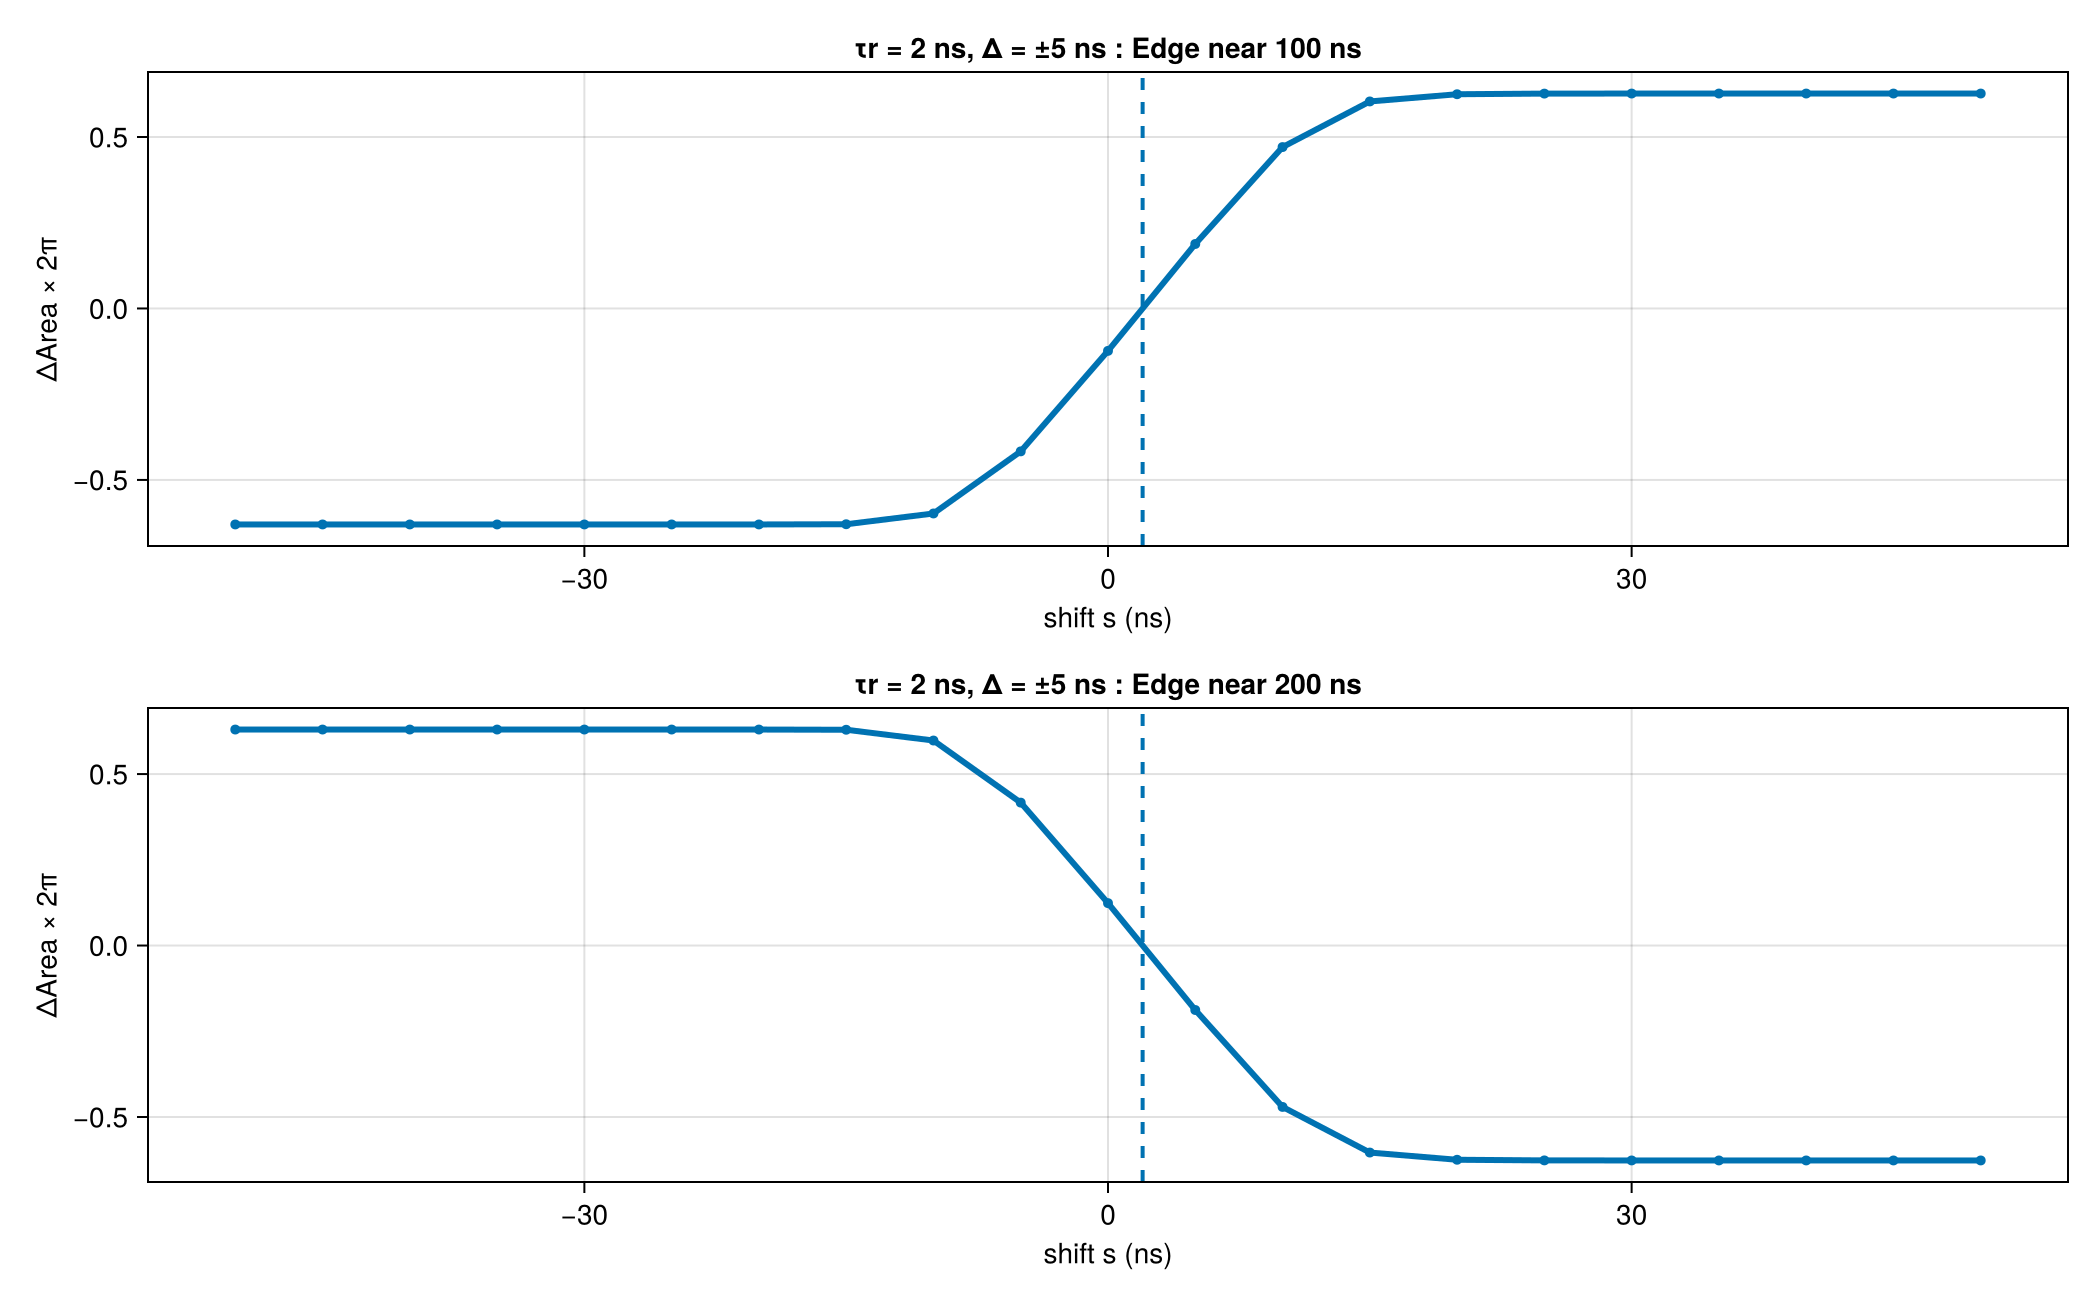

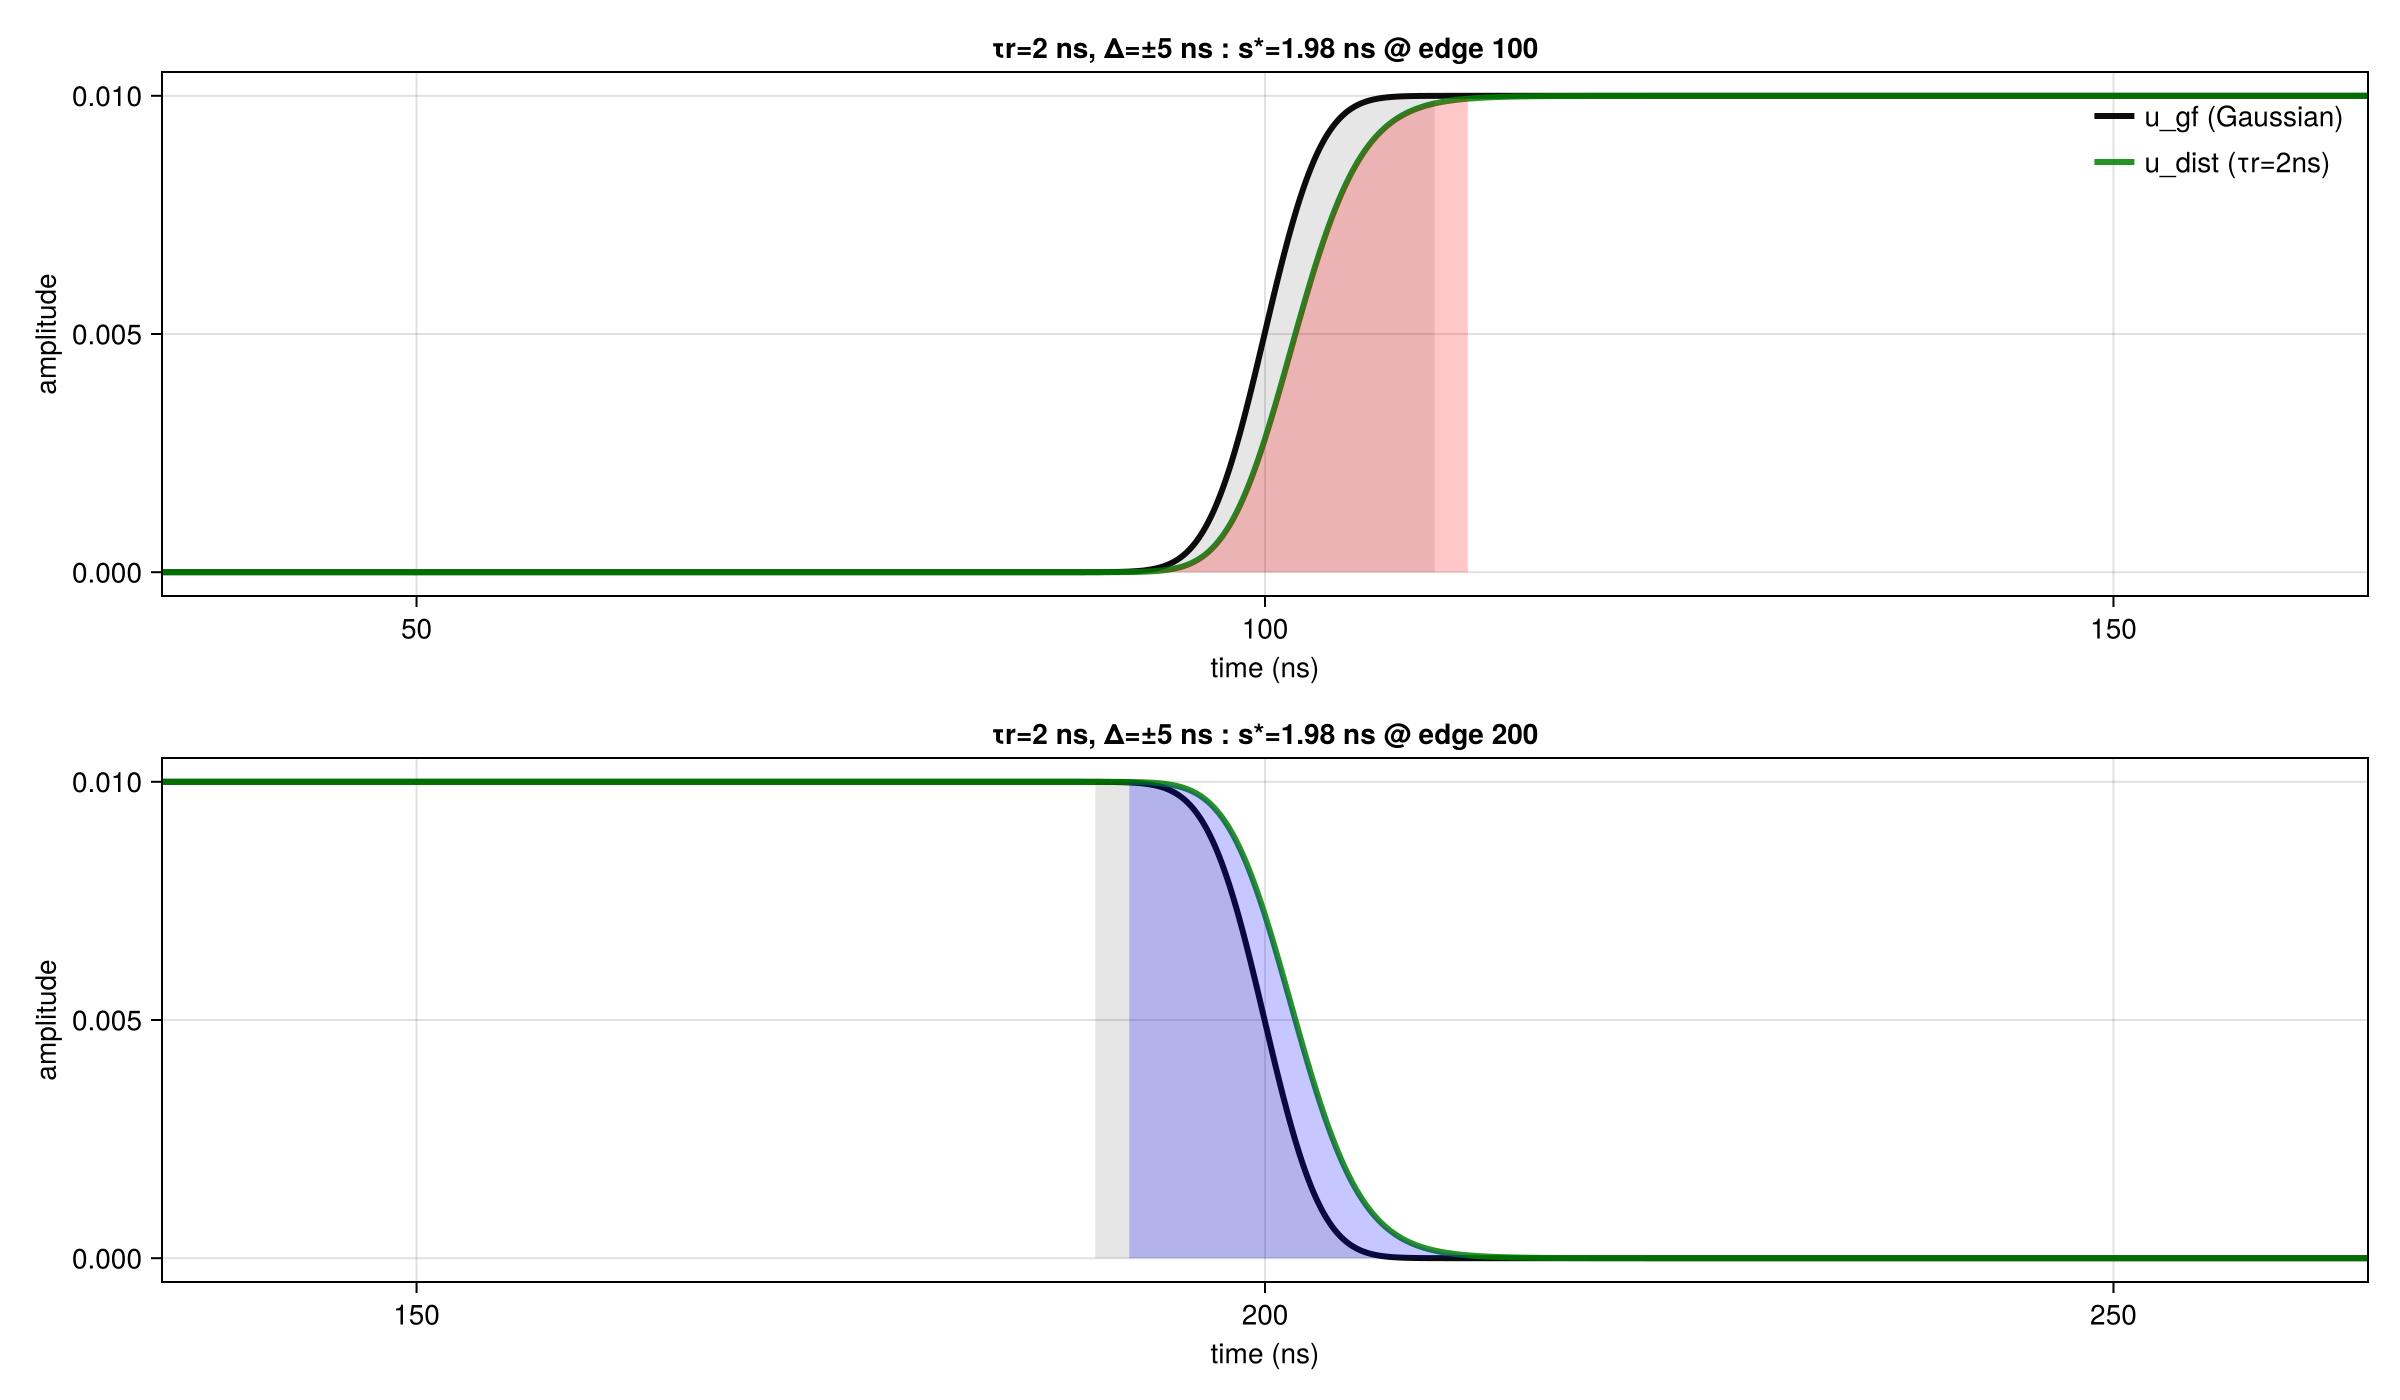

CairoMakie.Screen{IMAGE}


In [11]:
# ============================================================
# τr = 2 ns ONLY, Δ = 5 ns: line plot + shaded under-curve plot
# ============================================================

τr_sel = 2.0
Δ2     = 10.0

# IMPORTANT: symmetric shift scan so we can actually find ΔA(s)=0
shifts2 = collect(-50.0:5.0:50.0)

# distorted waveform for τr_sel
u_dist_2 = apply_exp_distortion(u_gf, f_ns; A=A, τr_ns=τr_sel)

# fixed Gaussian baseline areas (DO NOT SHIFT)
Agf1_fixed_2 = trapz_area_window(t_ns, u_gf, t_edge1-Δ2, t_edge1+Δ2)
Agf2_fixed_2 = trapz_area_window(t_ns, u_gf, t_edge2-Δ2, t_edge2+Δ2)

# compute ΔA(s)*2π for both edges
ΔA1_2 = Float64[]
ΔA2_2 = Float64[]

for s in shifts2
    c1 = t_edge1 + s
    c2 = t_edge2 + s

    Ad1 = trapz_area_window(t_ns, u_dist_2, c1-Δ2, c1+Δ2)
    Ad2 = trapz_area_window(t_ns, u_dist_2, c2-Δ2, c2+Δ2)

    push!(ΔA1_2, (Ad1 - Agf1_fixed_2) * 2π)
    push!(ΔA2_2, (Ad2 - Agf2_fixed_2) * 2π)
end

# ------------------------------------------------------------
# Find shifts s* where ΔA(s)=0 (interp if sign change exists)
# ------------------------------------------------------------
s1_star_2, how1_2 = find_root_shift(shifts2, ΔA1_2)
s2_star_2, how2_2 = find_root_shift(shifts2, ΔA2_2)

println("\n================ τr=2ns, Δ=5ns ROOT SHIFTS ================")
println("Edge 100ns: s* = $s1_star_2 ns   (method = $how1_2)")
println("Edge 200ns: s* = $s2_star_2 ns   (method = $how2_2)")
println("===========================================================\n")

# ============================================================
# (1) LINE PLOT: ΔA(s)*2π vs shift
# ============================================================
figL = Figure(size=(1050, 650))

axL1 = Axis(figL[1,1],
    xlabel="shift s (ns)",
    ylabel="ΔArea × 2π",
    title="τr = 2 ns, Δ = ±5 ns : Edge near 100 ns"
)
axL2 = Axis(figL[2,1],
    xlabel="shift s (ns)",
    ylabel="ΔArea × 2π",
    title="τr = 2 ns, Δ = ±5 ns : Edge near 200 ns"
)

lines!(axL1, shifts2, ΔA1_2; linewidth=3)
scatter!(axL1, shifts2, ΔA1_2; markersize=7)

lines!(axL2, shifts2, ΔA2_2; linewidth=3)
scatter!(axL2, shifts2, ΔA2_2; markersize=7)

# show s* as vertical line
vlines!(axL1, [s1_star_2]; linewidth=2, linestyle=:dash)
vlines!(axL2, [s2_star_2]; linewidth=2, linestyle=:dash)

display(figL)
# save("tau2ns_delta5ns_deltaA_vs_shift.png", figL)


# ============================================================
# (2) TIME-DOMAIN SHADING: under curve, using s*
# ============================================================
figS = Figure(size=(1200, 700))

axS1 = Axis(figS[1,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="τr=2 ns, Δ=±5 ns : s*=$(round(s1_star_2,digits=2)) ns @ edge 100"
)

axS2 = Axis(figS[2,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="τr=2 ns, Δ=±5 ns : s*=$(round(s2_star_2,digits=2)) ns @ edge 200"
)

# plot curves
for ax in (axS1, axS2)
    lines!(ax, t_ns, u_gf;     linewidth=3, color=(:black, 0.95), label="u_gf (Gaussian)")
    lines!(ax, t_ns, u_dist_2; linewidth=3, color=(:green, 0.85), label="u_dist (τr=2ns)")
end

# edge 100: fixed gaussian window + shifted distorted window
c1_fixed = t_edge1
c1_shift = t_edge1 + s1_star_2
shade_under_curve!(axS1, t_ns, u_gf,     c1_fixed-Δ2, c1_fixed+Δ2; color=(:black, 0.10))
shade_under_curve!(axS1, t_ns, u_dist_2, c1_shift-Δ2, c1_shift+Δ2; color=(:red,   0.22))

# edge 200
c2_fixed = t_edge2
c2_shift = t_edge2 + s2_star_2
shade_under_curve!(axS2, t_ns, u_gf,     c2_fixed-Δ2, c2_fixed+Δ2; color=(:black, 0.10))
shade_under_curve!(axS2, t_ns, u_dist_2, c2_shift-Δ2, c2_shift+Δ2; color=(:blue,  0.22))

axislegend(axS1; position=:rt, framevisible=false)

# zoom around windows so you actually see the shading
xlims!(axS1, (t_edge1 + minimum(shifts2)) - 15, (t_edge1 + maximum(shifts2)) + 15)
xlims!(axS2, (t_edge2 + minimum(shifts2)) - 15, (t_edge2 + maximum(shifts2)) + 15)

display(figS)
# save("tau2ns_delta5ns_shaded_time_domain.png", figS)

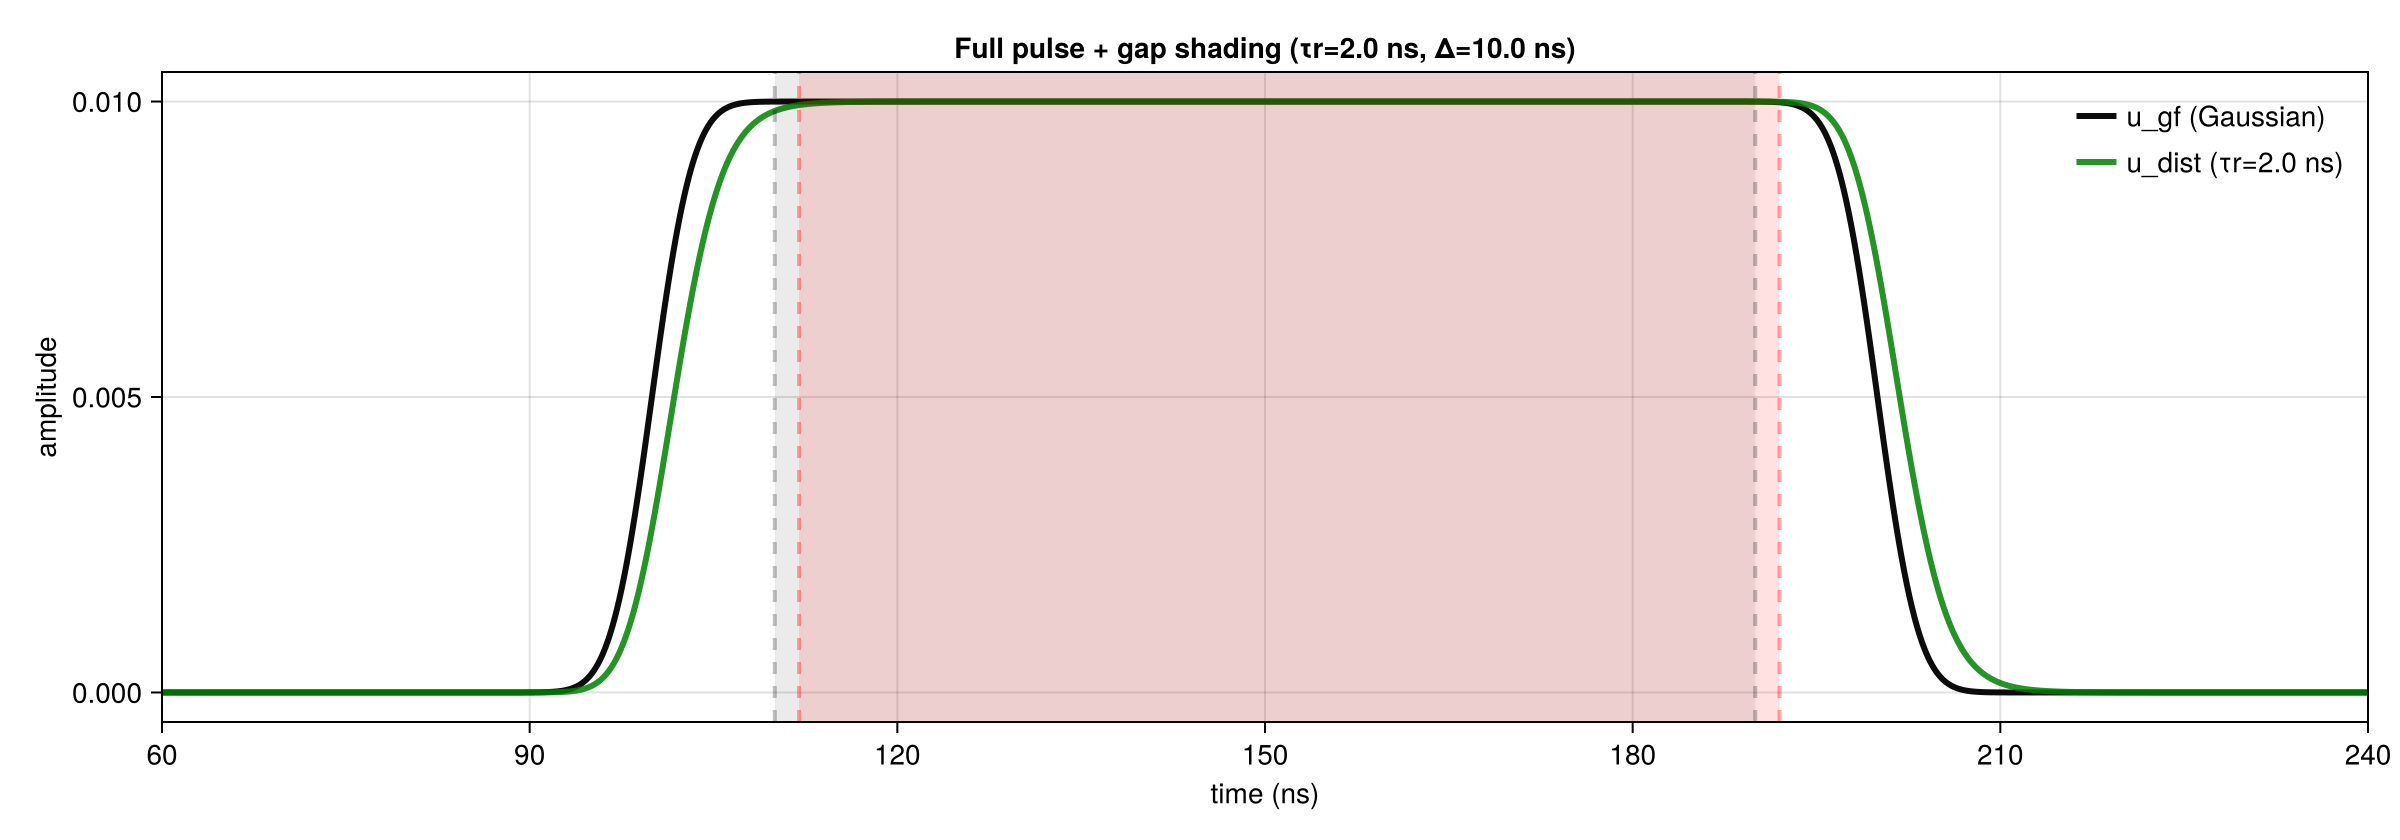

CairoMakie.Screen{IMAGE}


In [12]:
# ============================================================
# (3) FULL PULSE PLOT + SHADE THE TWO "GAP" REGIONS
#   - gap_gf   : end of 1st grey -> start of 2nd grey
#   - gap_dist : end of red      -> start of blue
# ============================================================

gap_gf_L   = t_edge1 + Δ2
gap_gf_R   = t_edge2 - Δ2

gap_dist_L = (t_edge1 + s1_star_2) + Δ2
gap_dist_R = (t_edge2 + s2_star_2) - Δ2

figF = Figure(size=(1200, 420))
axF = Axis(figF[1,1],
    xlabel="time (ns)",
    ylabel="amplitude",
    title="Full pulse + gap shading (τr=$(τr_sel) ns, Δ=$(Δ2) ns)"
)

# ---- plot full waveforms ----
lines!(axF, t_ns, u_gf;     linewidth=3, color=(:black, 0.95), label="u_gf (Gaussian)")
lines!(axF, t_ns, u_dist_2; linewidth=3, color=(:green, 0.85), label="u_dist (τr=$(τr_sel) ns)")

# ---- shade GF gap region (between grey windows) ----
if gap_gf_R > gap_gf_L
    vspan!(axF, gap_gf_L, gap_gf_R; color=(:black, 0.08))
end

# ---- shade DIST gap region (between red and blue windows) ----
if gap_dist_R > gap_dist_L
    vspan!(axF, gap_dist_L, gap_dist_R; color=(:red, 0.12))
end

# ---- OPTIONAL: draw vertical lines showing the exact boundaries ----
vlines!(axF, [gap_gf_L, gap_gf_R]; color=(:black, 0.25), linestyle=:dash, linewidth=2)
vlines!(axF, [gap_dist_L, gap_dist_R]; color=(:red, 0.35), linestyle=:dash, linewidth=2)

# zoom nicely around the two edges + middle
xlims!(axF, t_edge1 - 40, t_edge2 + 40)

axislegend(axF; position=:rt, framevisible=false)
display(figF)

# save("full_pulse_with_gap_regions.png", figF)

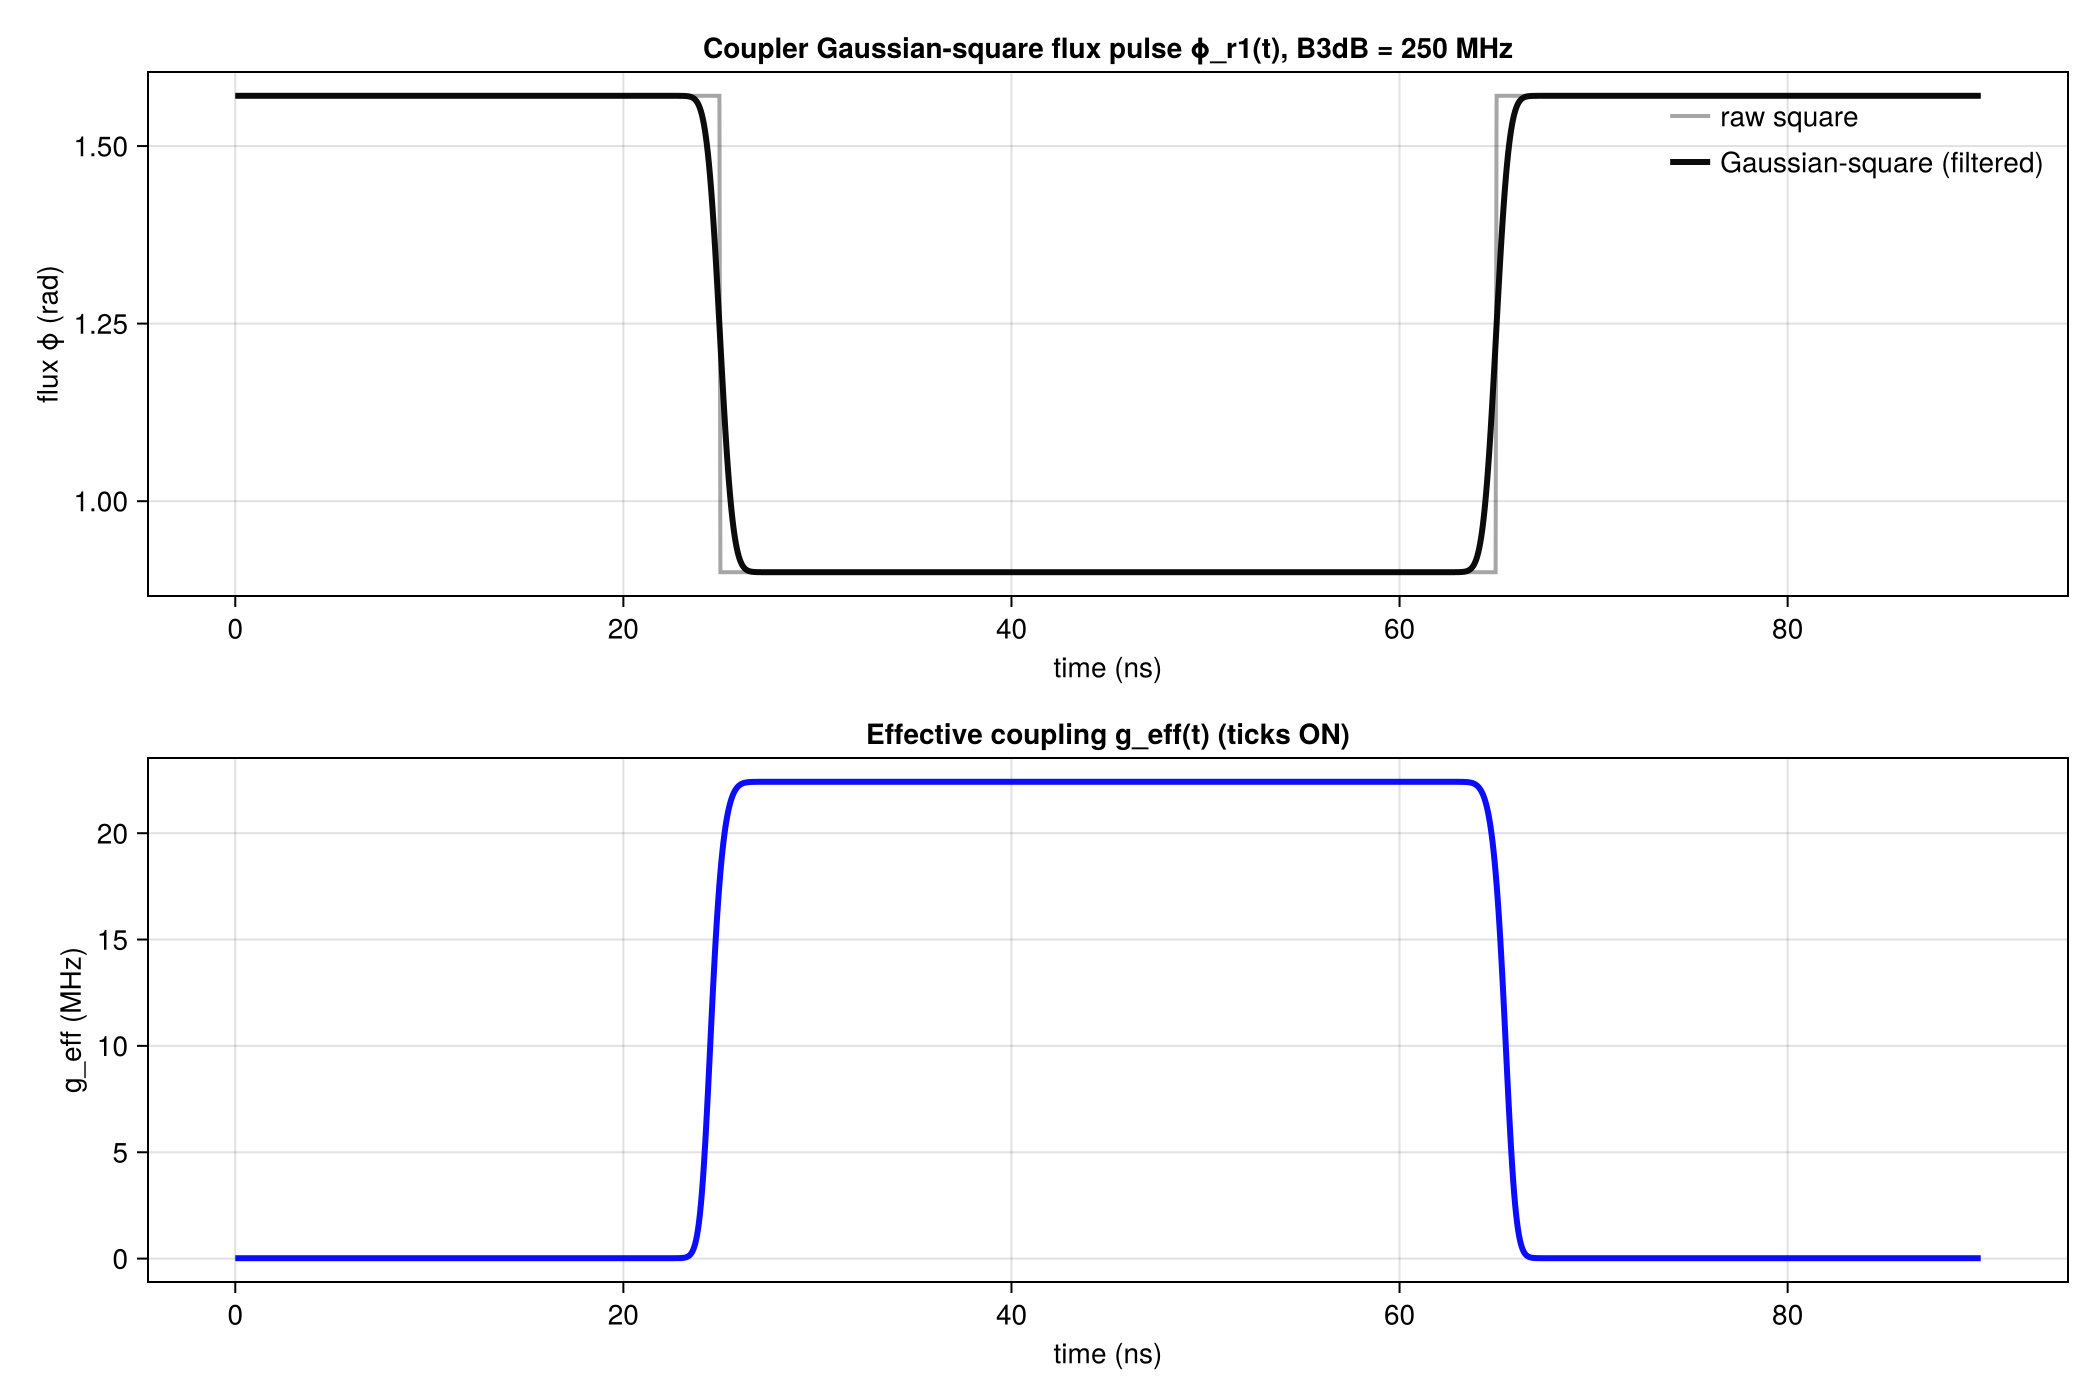

Saved geff_gaussian_square_flux.png
phi_off = 0.5π, phi_on = 0.2864788975654116π (symmetric about 0.375π)


In [13]:
using FFTW
using CairoMakie

# ============================================================
# 1) FFT frequency grid in cycles/ns (i.e. GHz), FFTW ordering
# ============================================================
function fftfreq_ns(N::Int, dt_ns::Float64)
    df = 1.0 / (N * dt_ns)  # cycles/ns
    k  = [j <= N ÷ 2 ? j : j - N for j in 0:N-1]
    return df .* k
end

# ============================================================
# 2) Gaussian LPF transfer function
#    |G(f)| = exp(-0.5 * f^2 / σ^2)
#    choose σ so that |G(B3dB)| = 1/sqrt(2)
# ============================================================
function gaussian_lpf_transfer(f_cyc_per_ns::Vector{Float64}, B3dB_MHz::Float64)
    B3dB_cyc_per_ns = B3dB_MHz / 1000.0          # 250 MHz -> 0.25 cycles/ns
    σ = B3dB_cyc_per_ns / sqrt(log(2.0))         # exp(-0.5*(B3dB^2)/σ^2)=1/√2
    return @. exp(-0.5 * (f_cyc_per_ns^2) / σ^2)
end

# ============================================================
# 3) Build Gaussian-square flux pulse (filtered square)
#    All time units are ns, flux is radians
#
# IMPORTANT:
# We filter only the delta from the baseline:
#   dphi(t) = phi_raw(t) - phi_base
# so the off-point stays EXACT.
# ============================================================
function gaussian_square_flux_ns(;
    width_ns::Float64 = 40.0,
    pre_ns::Float64   = 25.0,
    post_ns::Float64  = 25.0,
    dt_ns::Float64    = 0.05,
    B3dB_MHz::Float64 = 250.0,
    phi_base::Float64 = 0.30*pi,   # baseline (off)
    phi_pulse::Float64 = 0.45*pi   # plateau value (on)
)
    total_ns = pre_ns + width_ns + post_ns
    N = Int(round(total_ns / dt_ns))
    t_ns = (0:N-1) .* dt_ns

    # raw square in flux
    phi_raw = fill(phi_base, N)
    i0 = Int(round(pre_ns / dt_ns)) + 1
    i1 = i0 + Int(round(width_ns / dt_ns)) - 1
    phi_raw[i0:i1] .= phi_pulse

    # filter delta from baseline (keeps exact baseline)
    dphi = phi_raw .- phi_base

    f_ns = fftfreq_ns(N, dt_ns)
    G = gaussian_lpf_transfer(f_ns, B3dB_MHz)

    dphi_filt = real.(ifft(G .* fft(dphi)))
    phi_filt = phi_base .+ dphi_filt

    return t_ns, phi_raw, phi_filt
end

# ============================================================
# 4) Effective-model formulas (same as your Python)
# ============================================================
struct EffectiveModel
    E_J0_q1::Float64
    E_J0_q2::Float64
    E_J0_r1::Float64
    E_C_q1::Float64
    E_C_q2::Float64
    E_C_r1::Float64
    E_C_q1r1::Float64
    E_C_q2r1::Float64
    E_C_q1q2::Float64
end

josephson_energy(E_J0, phi_ext) = E_J0 * abs(cos(phi_ext / 2.0))
mode_frequency(E_J, E_C) = sqrt(8.0 * E_J * E_C) - E_C

coupling(E_Jk, E_Ck, E_Jl, E_Cl, E_Ckl) =
    E_Ckl / sqrt(2.0) * (E_Jk * E_Jl / (E_Ck * E_Cl))^0.25

function effective_coupling(g1, g2, g12, ωq1, ωq2, ωr1)
    Δ1 = ωq1 - ωr1
    Δ2 = ωq2 - ωr1
    return g12 + 0.5*g1*g2*(1/Δ1 + 1/Δ2)  # same approx as your Python
end

function compute_params(m::EffectiveModel, phi_q1, phi_q2, phi_r1)
    E_J_q1 = josephson_energy(m.E_J0_q1, phi_q1)
    E_J_q2 = josephson_energy(m.E_J0_q2, phi_q2)
    E_J_r1 = josephson_energy(m.E_J0_r1, phi_r1)

    # same as your Python: omega = 2π * mode_frequency(...)
    ωq1 = 2π * mode_frequency(E_J_q1, m.E_C_q1)
    ωq2 = 2π * mode_frequency(E_J_q2, m.E_C_q2)
    ωr1 = 2π * mode_frequency(E_J_r1, m.E_C_r1)

    g_q1q2 = 2π * coupling(E_J_q1, m.E_C_q1, E_J_q2, m.E_C_q2, m.E_C_q1q2)
    g_q1r1 = 2π * coupling(E_J_q1, m.E_C_q1, E_J_r1, m.E_C_r1, m.E_C_q1r1)
    g_q2r1 = 2π * coupling(E_J_q2, m.E_C_q2, E_J_r1, m.E_C_r1, m.E_C_q2r1)

    return ωq1, ωq2, ωr1, g_q1q2, g_q1r1, g_q2r1
end

function geff_trace(m::EffectiveModel,
    phi_q1_t::Vector{Float64},
    phi_q2_t::Vector{Float64},
    phi_r1_t::Vector{Float64}
)
    N = length(phi_q1_t)
    @assert length(phi_q2_t) == N && length(phi_r1_t) == N

    geff = zeros(Float64, N)  # rad/ns

    @inbounds for k in 1:N
        ωq1, ωq2, ωr1, g_q1q2, g_q1r1, g_q2r1 = compute_params(m, phi_q1_t[k], phi_q2_t[k], phi_r1_t[k])
        geff[k] = effective_coupling(g_q1r1, g_q2r1, g_q1q2, ωq1, ωq2, ωr1)
    end

    return geff
end

# ============================================================
# 5) Run: Gaussian-square on coupler flux φ_r1(t)
#    AND make OFF/ON "opposite" (symmetric about midpoint)
# ============================================================
m = EffectiveModel(
    20.0, 20.0, 30.0,
    0.25, 0.25, 0.25,
    0.02, 0.02, 0.006
)

# fixed qubit flux biases
phi_q1_const = 0.25*pi
phi_q2_const = 0.25*pi

# ---- symmetric off/on about a midpoint ----
phi_mid = 0.375*pi
dphi    = 0.075*pi
phi_off = pi/2
phi_on  = 0.9

t_ns, phi_r1_raw, phi_r1_filt = gaussian_square_flux_ns(
    width_ns   = 40.0,
    pre_ns     = 25.0,
    post_ns    = 25.0,
    dt_ns      = 0.05,
    B3dB_MHz   = 250.0,
    phi_base   = phi_off,
    phi_pulse  = phi_on
)

phi_q1_t = fill(phi_q1_const, length(t_ns))
phi_q2_t = fill(phi_q2_const, length(t_ns))
phi_r1_t = phi_r1_filt

geff_rad_per_ns = geff_trace(m, phi_q1_t, phi_q2_t, phi_r1_t)

# convert rad/ns -> MHz:
#   (rad/ns)/(2π) = cycles/ns = GHz, then *1000 = MHz
geff_MHz = (geff_rad_per_ns ./ (2π)) .* 1000.0

# ============================================================
# 6) Plot (KEEP Y-AXIS TICKS ON g_eff!)
# ============================================================
fig = Figure(size=(1050, 700))

ax1 = Axis(fig[1,1],
    xlabel="time (ns)",
    ylabel="flux ϕ (rad)",
    title="Coupler Gaussian-square flux pulse ϕ_r1(t), B3dB = 250 MHz"
)
lines!(ax1, t_ns, phi_r1_raw;  linewidth=2, color=(:black, 0.35), label="raw square")
lines!(ax1, t_ns, phi_r1_filt; linewidth=3, color=(:black, 0.95), label="Gaussian-square (filtered)")
axislegend(ax1; position=:rt, framevisible=false)

ax2 = Axis(fig[2,1],
    xlabel="time (ns)",
    ylabel="g_eff (MHz)",
    title="Effective coupling g_eff(t) (ticks ON)"
)
lines!(ax2, t_ns, geff_MHz; linewidth=3, color=(:blue, 0.95))
# NOTE: do NOT call hidedecorations! (that removes the y-axis markers)

display(fig)
save("geff_gaussian_square_flux.png", fig)

println("Saved geff_gaussian_square_flux.png")
println("phi_off = $(phi_off/pi)π, phi_on = $(phi_on/pi)π (symmetric about $(phi_mid/pi)π)")

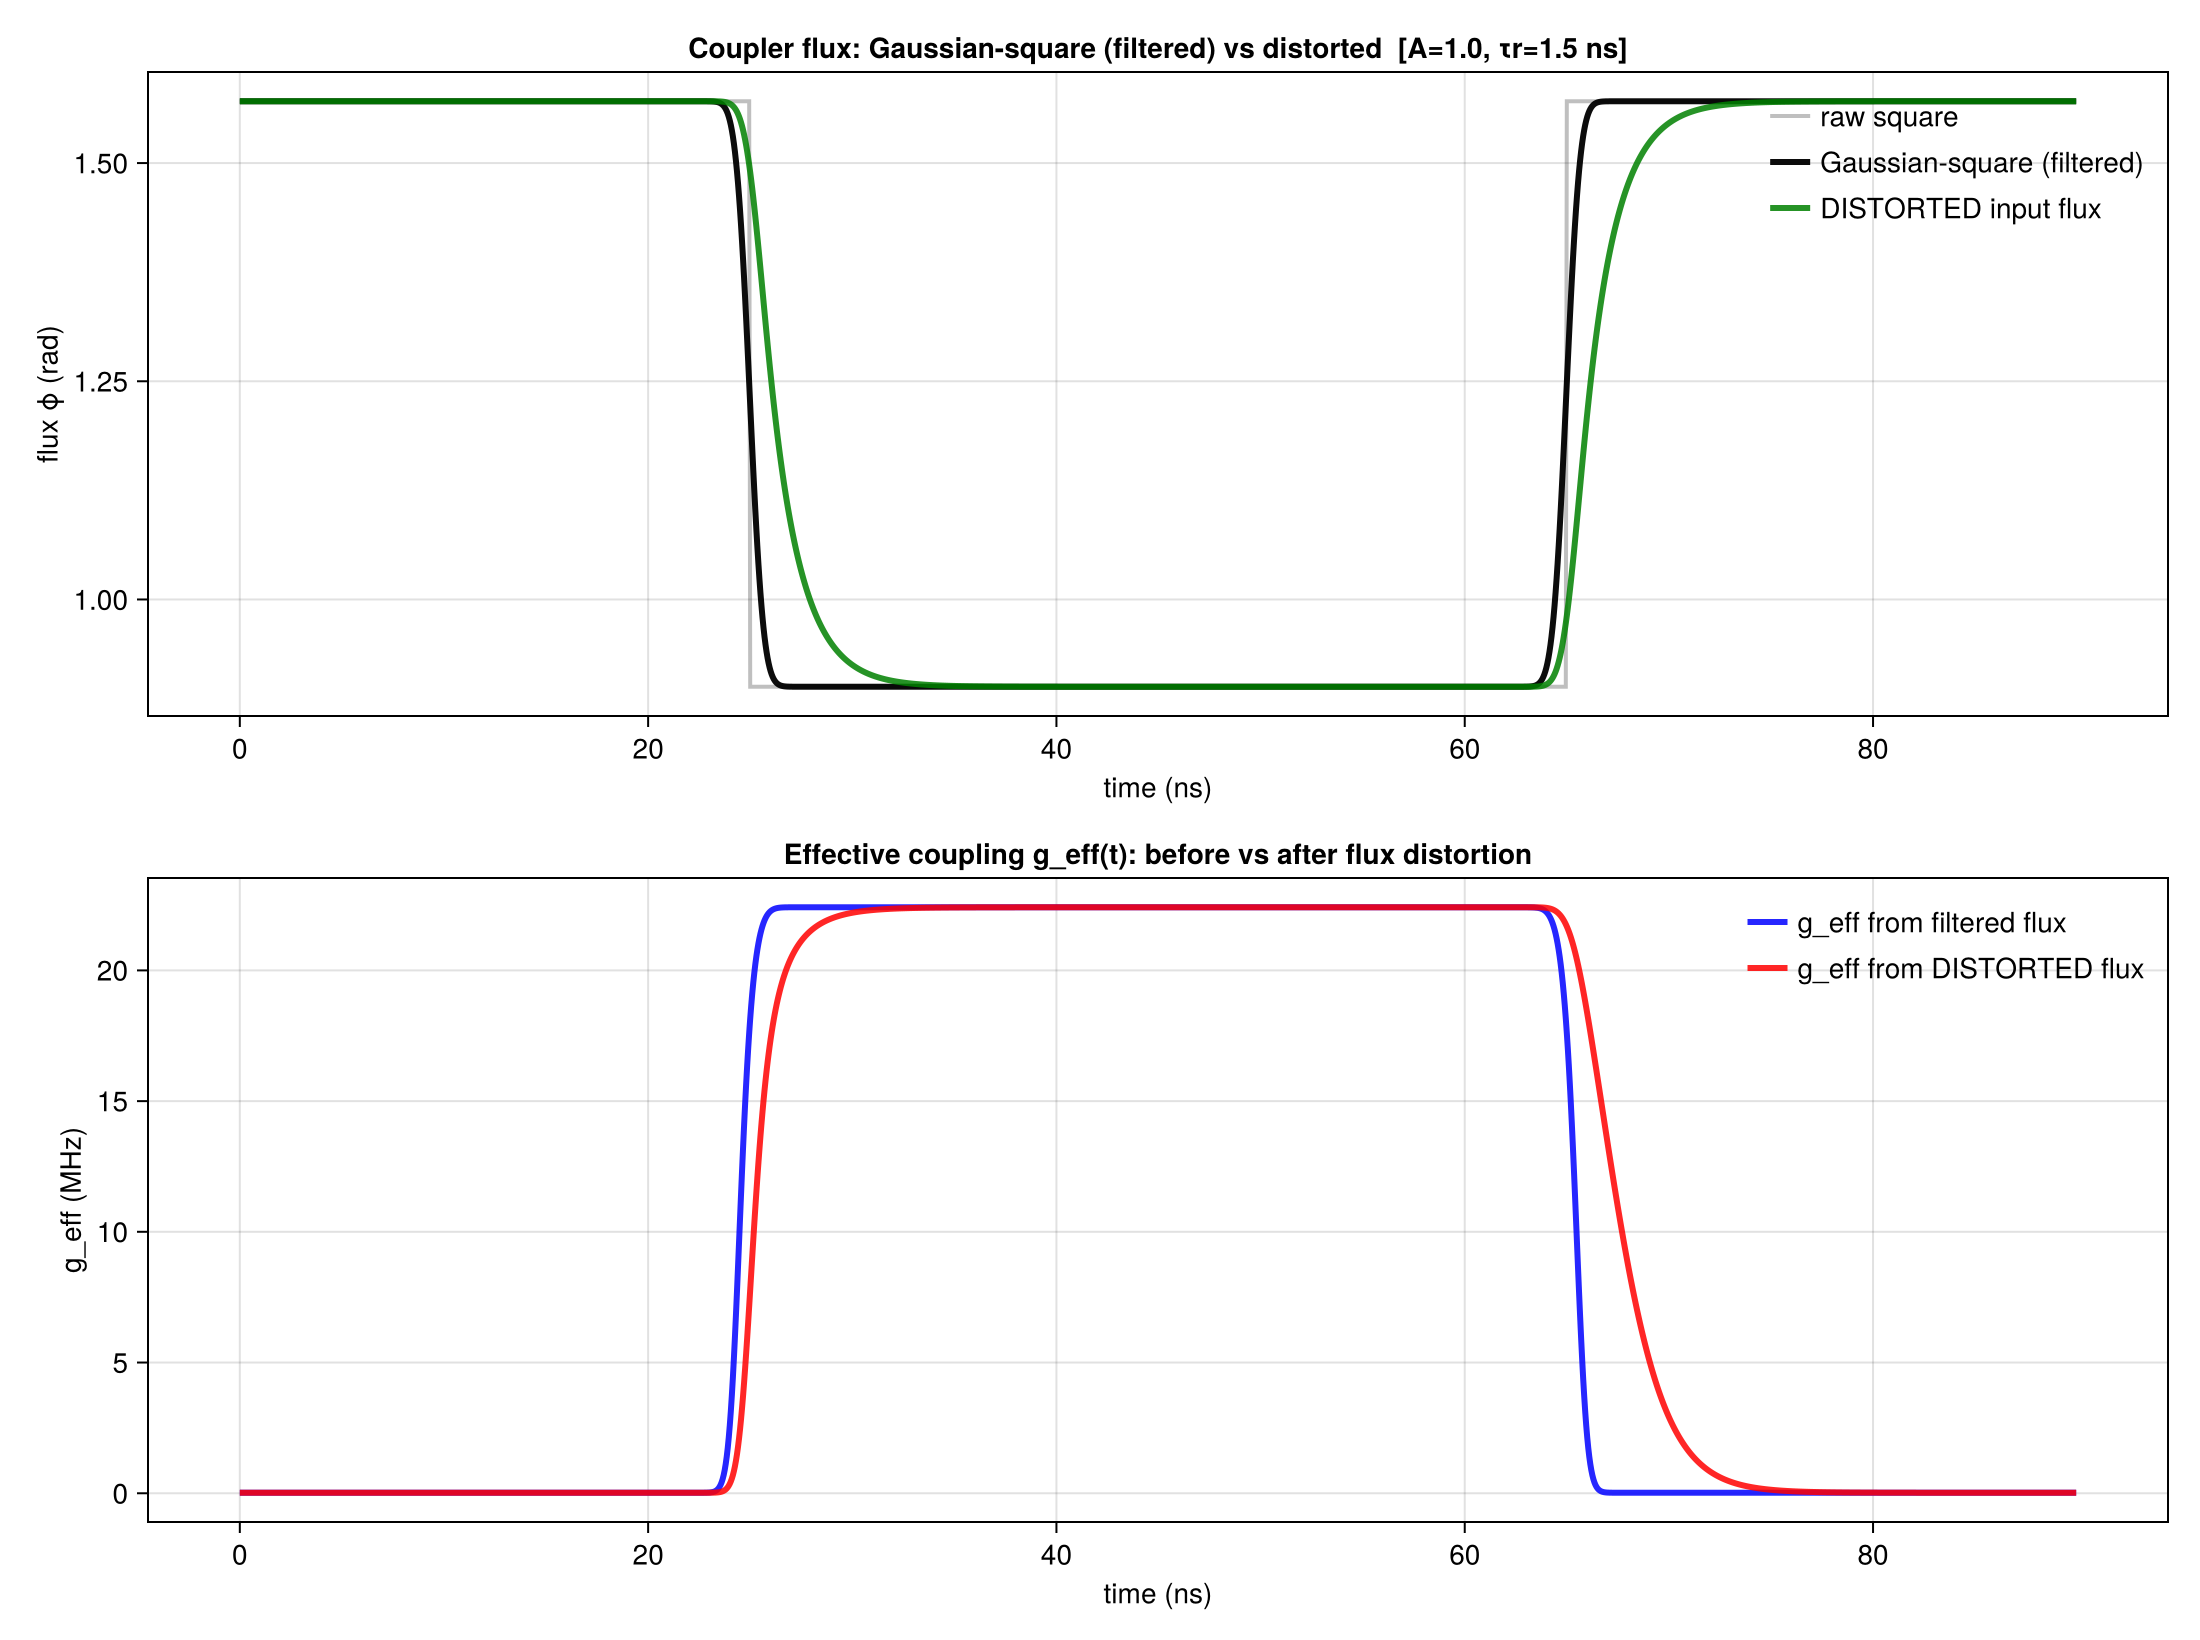

Saved geff_with_flux_distortion.png
Distortion applied ONLY to flux input: A=1.0, tau_r=1.5 ns
Baseline preserved at phi_off = 1.5707963267948966 rad


In [22]:
# ============================================================
# Distort ONLY the input flux ϕ_r1(t) (do NOT change model params)
#   - Distort the delta: dϕ(t) = ϕ(t) - ϕ_off
#   - Keep baseline exactly: ϕ_dist(t) = ϕ_off + Distort(dϕ)
# ============================================================

# -------------------------
# Exponential distortion transfer function in frequency domain
# H(ω) = A / (1 + i ω τr), ω = 2π f
# f is cycles/ns, τr is ns
# -------------------------
function apply_exp_distortion_freq(u_in::Vector{Float64}, f_ns::Vector{Float64};
    A::Float64 = 1.35,
    τr_ns::Float64 = 1.5
)
    ω_ns = 2π .* f_ns
    Hexp = @. A / (1 + 1im * ω_ns * τr_ns)
    return real.(ifft(Hexp .* fft(u_in)))
end

# -------------------------
# Distort flux waveform but preserve exact baseline (off-point)
# -------------------------
function distort_flux_preserve_baseline(phi_in::Vector{Float64}, f_ns::Vector{Float64};
    phi_base::Float64,
    A::Float64 = 1.35,
    τr_ns::Float64 = 1.5
)
    dphi = phi_in .- phi_base
    dphi_dist = apply_exp_distortion_freq(dphi, f_ns; A=A, τr_ns=τr_ns)
    return phi_base .+ dphi_dist
end

# ============================================================
# Apply distortion to the coupler flux (input)
# ============================================================
A_dist   = 1.0
tau_r_ns = 1.5

phi_r1_dist = distort_flux_preserve_baseline(phi_r1_filt, fftfreq_ns(length(phi_r1_filt), t_ns[2]-t_ns[1]);
    phi_base = phi_off,
    A = A_dist,
    τr_ns = tau_r_ns
)

# Recompute g_eff(t) using the distorted flux trace
geff_rad_per_ns_dist = geff_trace(m, phi_q1_t, phi_q2_t, phi_r1_dist)
geff_MHz_dist = (geff_rad_per_ns_dist ./ (2π)) .* 1000.0

# ============================================================
# Plot: flux BEFORE/AFTER distortion + g_eff BEFORE/AFTER
# ============================================================
figD = Figure(size=(1100, 820))

axF = Axis(figD[1,1],
    xlabel="time (ns)",
    ylabel="flux ϕ (rad)",
    title="Coupler flux: Gaussian-square (filtered) vs distorted  [A=$(A_dist), τr=$(tau_r_ns) ns]"
)
lines!(axF, t_ns, phi_r1_raw;  linewidth=2, color=(:black, 0.25), label="raw square")
lines!(axF, t_ns, phi_r1_filt; linewidth=3, color=(:black, 0.95), label="Gaussian-square (filtered)")
lines!(axF, t_ns, phi_r1_dist; linewidth=3, color=(:green, 0.85), label="DISTORTED input flux")
axislegend(axF; position=:rt, framevisible=false)

axG = Axis(figD[2,1],
    xlabel="time (ns)",
    ylabel="g_eff (MHz)",
    title="Effective coupling g_eff(t): before vs after flux distortion"
)
lines!(axG, t_ns, geff_MHz;      linewidth=3, color=(:blue, 0.85), label="g_eff from filtered flux")
lines!(axG, t_ns, geff_MHz_dist; linewidth=3, color=(:red, 0.85),  label="g_eff from DISTORTED flux")
axislegend(axG; position=:rt, framevisible=false)

display(figD)
#save("geff_with_flux_distortion.png", figD)

println("Saved geff_with_flux_distortion.png")
println("Distortion applied ONLY to flux input: A=$(A_dist), tau_r=$(tau_r_ns) ns")
println("Baseline preserved at phi_off = $(phi_off) rad")

t range = [0.0, 89.95]
edge1=25.0 valid shifts: [-10.0, 10.0]  (N=5)
edge2=65.0 valid shifts: [-10.0, 10.0]  (N=5)

================ g_eff ROOT SHIFTS (ΔA=0) ================
Δ = ±10.0 ns, baseline window fixed, distorted window shifts
Edge @ 25.0 ns: s* = 0.9534135614169743 ns   (method=interp)
Edge @ 65.0 ns: s* = 2.396964975503813 ns   (method=interp)



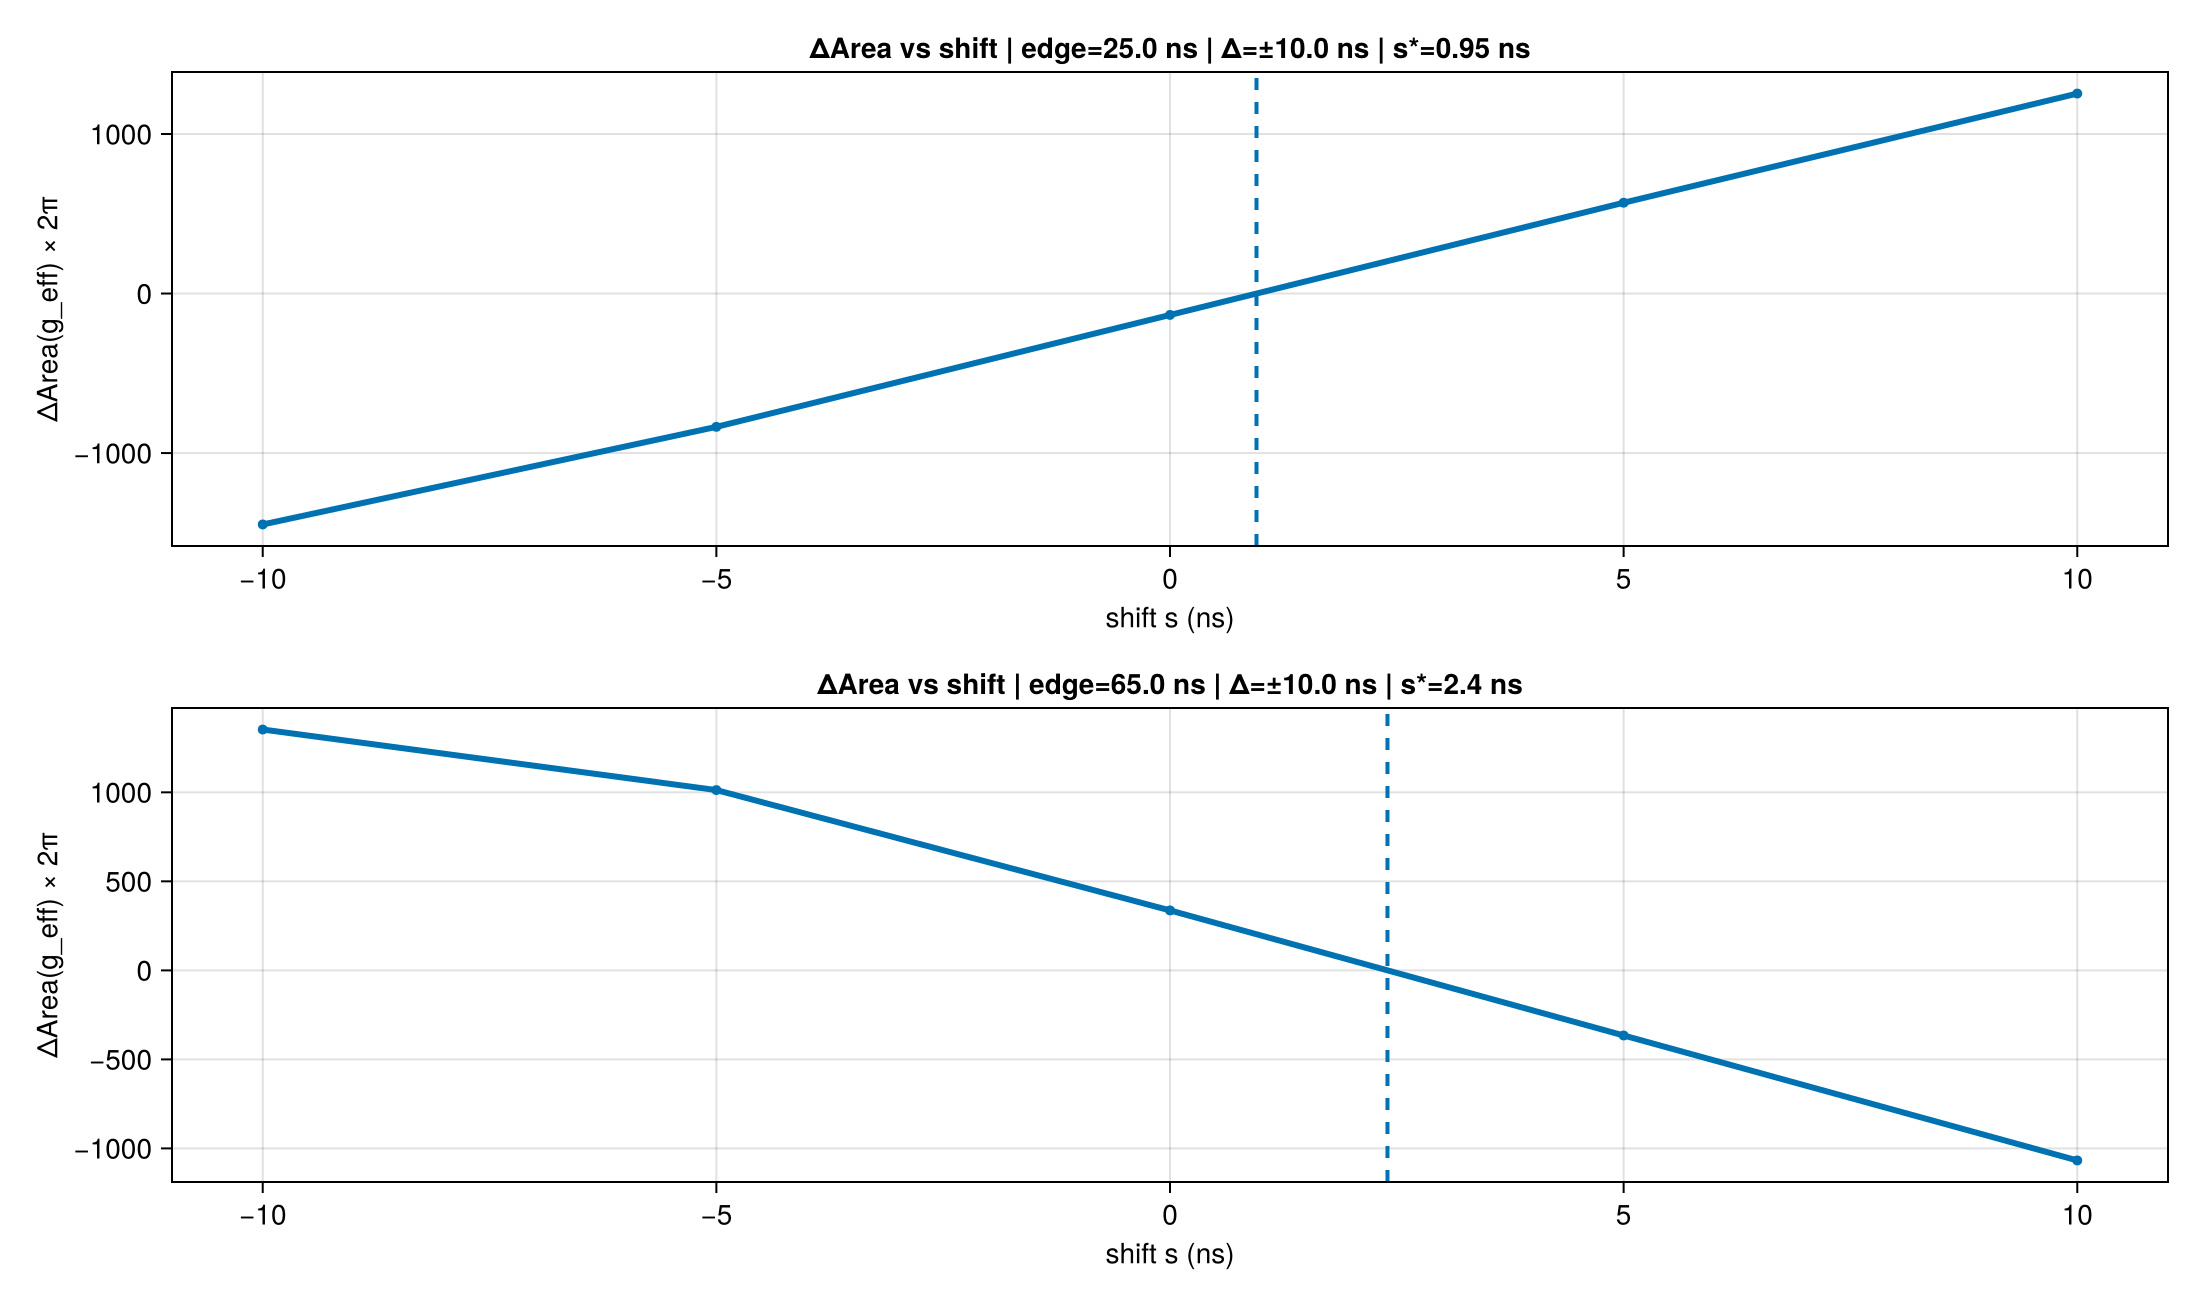

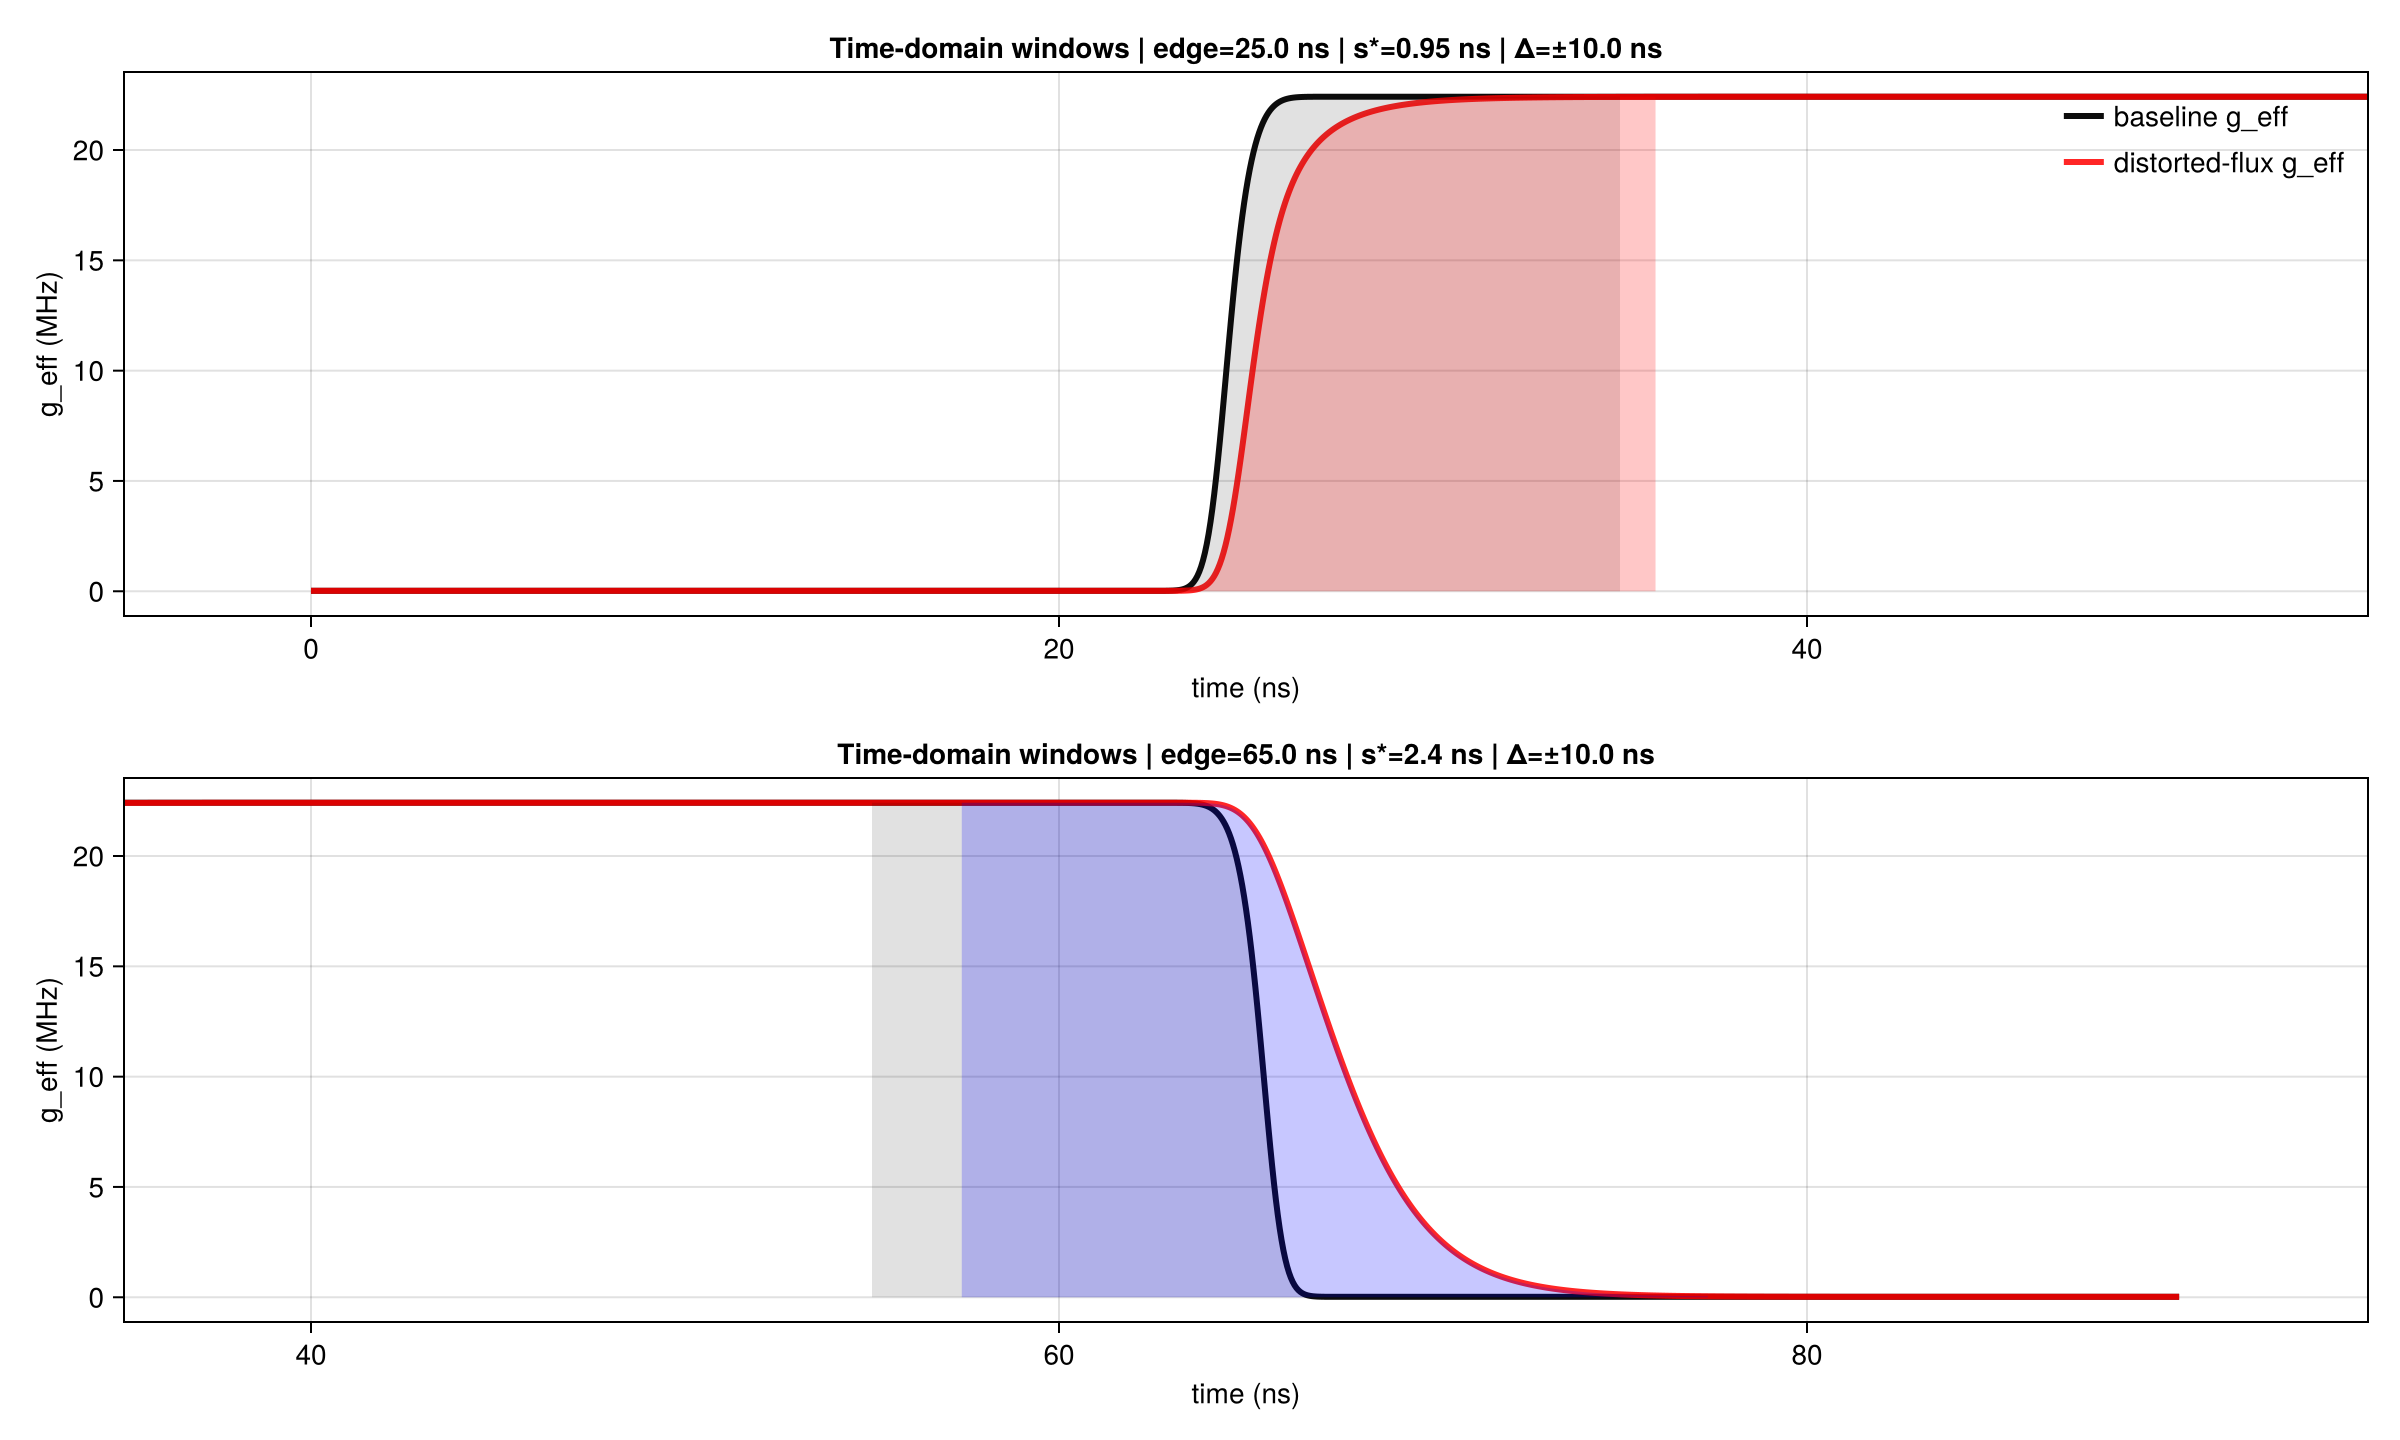

CairoMakie.Screen{IMAGE}


In [24]:
using CairoMakie

# ============================================================
# FULL SELF-CONTAINED CODE CELL:
#   ΔArea(s)×2π vs shift + time-domain shading for g_eff(t)
# ============================================================

# ------------------------------------------------------------
# REQUIRED INPUTS (must already exist in your notebook/session)
# ------------------------------------------------------------
@assert @isdefined(t_ns)         "You must define t_ns first"
@assert @isdefined(geff_MHz)     "You must define geff_MHz first"
@assert @isdefined(geff_MHz_dist) "You must define geff_MHz_dist first"

@assert length(t_ns) == length(geff_MHz) == length(geff_MHz_dist)

# ============================================================
# Helpers
# ============================================================

# trapezoid area integral on window [tL, tR]
function trapz_area_window(
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Real,
    tR::Real
)
    @assert length(t) == length(y)

    tL = Float64(tL)
    tR = Float64(tR)
    if tR < tL
        tL, tR = tR, tL
    end

    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return 0.0
    end

    s = 0.0
    @inbounds for k in 1:length(idx)-1
        i = idx[k]
        j = idx[k+1]
        dt = float(t[j] - t[i])
        s += 0.5 * dt * (float(y[i]) + float(y[j]))
    end
    return s
end

# shade area UNDER curve y(t) over [tL,tR] down to baseline=0
function shade_under_curve!(
    ax,
    t::AbstractVector{<:Real},
    y::AbstractVector{<:Real},
    tL::Real,
    tR::Real;
    color = (:red, 0.18)
)
    tL = Float64(tL)
    tR = Float64(tR)
    if tR < tL
        tL, tR = tR, tL
    end

    idx = findall(tt -> (tt >= tL && tt <= tR), t)
    if length(idx) < 2
        return
    end

    tw = Float64.(t[idx])
    yw = Float64.(y[idx])

    xs = vcat(tw, reverse(tw))
    ys = vcat(yw, zeros(length(yw)))

    poly!(ax, xs, ys; color=color, strokewidth=0)
end

# find s* where f(s)=0 using sign change + linear interpolation
# if no sign change: closest-to-zero value
function find_root_shift(shifts::AbstractVector{<:Real}, fvals::AbstractVector{<:Real})
    s = Float64.(shifts)
    f = Float64.(fvals)

    for k in 1:length(s)-1
        f0, f1 = f[k], f[k+1]
        if f0 == 0
            return s[k], :exact
        end
        if f0 * f1 < 0
            s0, s1 = s[k], s[k+1]
            s_star = s0 + (0 - f0) * (s1 - s0) / (f1 - f0)
            return s_star, :interp
        end
    end

    kbest = argmin(abs.(f))
    return s[kbest], :closest
end

# ============================================================
# USER SETTINGS
# ============================================================

# You said these are your "edges"
t_edge1 = 25.0
t_edge2 = 65.0

Δg = 10.0                      # half-width (ns)
shift_step = 5.0              # shift grid step (ns)
shift_span = 10.0             # nominal scan extent ±span

# initial shift grid (we will FILTER it so windows never go OOB)
shifts_grid = collect(-shift_span:shift_step:shift_span)

# ============================================================
# SAFETY: filter shifts so shifted window stays inside time grid
# ============================================================

tmin = Float64(first(t_ns))
tmax = Float64(last(t_ns))

function valid_shifts_for_edge(shifts_grid, t_edge, Δg, tmin, tmax)
    [s for s in shifts_grid if ((t_edge + s - Δg) >= tmin && (t_edge + s + Δg) <= tmax)]
end

shifts1 = valid_shifts_for_edge(shifts_grid, t_edge1, Δg, tmin, tmax)
shifts2 = valid_shifts_for_edge(shifts_grid, t_edge2, Δg, tmin, tmax)

println("t range = [$tmin, $tmax]")
println("edge1=$t_edge1 valid shifts: [$(minimum(shifts1)), $(maximum(shifts1))]  (N=$(length(shifts1)))")
println("edge2=$t_edge2 valid shifts: [$(minimum(shifts2)), $(maximum(shifts2))]  (N=$(length(shifts2)))")

# ============================================================
# BASELINE FIXED AREAS (DO NOT SHIFT)
# ============================================================

A_base_1 = trapz_area_window(t_ns, geff_MHz, t_edge1-Δg, t_edge1+Δg)
A_base_2 = trapz_area_window(t_ns, geff_MHz, t_edge2-Δg, t_edge2+Δg)

# ============================================================
# ΔA(s) = A_dist(shifted) - A_base(fixed), multiplied by 2π
# ============================================================

ΔA1 = Float64[]
for s in shifts1
    c1 = t_edge1 + s
    A_dist_1 = trapz_area_window(t_ns, geff_MHz_dist, c1-Δg, c1+Δg)
    push!(ΔA1, (A_dist_1 - A_base_1) * 2π)
end

ΔA2 = Float64[]
for s in shifts2
    c2 = t_edge2 + s
    A_dist_2 = trapz_area_window(t_ns, geff_MHz_dist, c2-Δg, c2+Δg)
    push!(ΔA2, (A_dist_2 - A_base_2) * 2π)
end

# ============================================================
# Find root shifts s* where ΔA(s) ≈ 0
# ============================================================

s1_star, how1 = find_root_shift(shifts1, ΔA1)
s2_star, how2 = find_root_shift(shifts2, ΔA2)

println("\n================ g_eff ROOT SHIFTS (ΔA=0) ================")
println("Δ = ±$(Δg) ns, baseline window fixed, distorted window shifts")
println("Edge @ $(t_edge1) ns: s* = $(s1_star) ns   (method=$(how1))")
println("Edge @ $(t_edge2) ns: s* = $(s2_star) ns   (method=$(how2))")
println("==========================================================\n")

# ============================================================
# (1) LINE PLOTS: ΔA(s)×2π vs shift
# ============================================================

figL = Figure(size=(1100, 650))

axL1 = Axis(figL[1,1],
    xlabel="shift s (ns)",
    ylabel="ΔArea(g_eff) × 2π",
    title="ΔArea vs shift | edge=$(t_edge1) ns | Δ=±$(Δg) ns | s*=$(round(s1_star,digits=2)) ns"
)

axL2 = Axis(figL[2,1],
    xlabel="shift s (ns)",
    ylabel="ΔArea(g_eff) × 2π",
    title="ΔArea vs shift | edge=$(t_edge2) ns | Δ=±$(Δg) ns | s*=$(round(s2_star,digits=2)) ns"
)

lines!(axL1, shifts1, ΔA1; linewidth=3)
scatter!(axL1, shifts1, ΔA1; markersize=7)
vlines!(axL1, [s1_star]; linewidth=2, linestyle=:dash)

lines!(axL2, shifts2, ΔA2; linewidth=3)
scatter!(axL2, shifts2, ΔA2; markersize=7)
vlines!(axL2, [s2_star]; linewidth=2, linestyle=:dash)

display(figL)

# ============================================================
# (2) TIME-DOMAIN SHADING PLOT: baseline window vs shifted window
# ============================================================

figS = Figure(size=(1200, 720))

axS1 = Axis(figS[1,1],
    xlabel="time (ns)",
    ylabel="g_eff (MHz)",
    title="Time-domain windows | edge=$(t_edge1) ns | s*=$(round(s1_star,digits=2)) ns | Δ=±$(Δg) ns"
)

axS2 = Axis(figS[2,1],
    xlabel="time (ns)",
    ylabel="g_eff (MHz)",
    title="Time-domain windows | edge=$(t_edge2) ns | s*=$(round(s2_star,digits=2)) ns | Δ=±$(Δg) ns"
)

# plot both curves on both axes
for ax in (axS1, axS2)
    lines!(ax, t_ns, geff_MHz;      linewidth=3, color=(:black, 0.95), label="baseline g_eff")
    lines!(ax, t_ns, geff_MHz_dist; linewidth=3, color=(:red,   0.85), label="distorted-flux g_eff")
end

# edge 1 shading
shade_under_curve!(axS1, t_ns, geff_MHz,      t_edge1-Δg,           t_edge1+Δg;           color=(:black, 0.12))
shade_under_curve!(axS1, t_ns, geff_MHz_dist, (t_edge1+s1_star)-Δg, (t_edge1+s1_star)+Δg; color=(:red,   0.22))

# edge 2 shading
shade_under_curve!(axS2, t_ns, geff_MHz,      t_edge2-Δg,           t_edge2+Δg;           color=(:black, 0.12))
shade_under_curve!(axS2, t_ns, geff_MHz_dist, (t_edge2+s2_star)-Δg, (t_edge2+s2_star)+Δg; color=(:blue,  0.22))

axislegend(axS1; position=:rt, framevisible=false)

# zoom around each edge so shading is visible
xlims!(axS1, (t_edge1 + minimum(shifts1)) - 20, (t_edge1 + maximum(shifts1)) + 20)
xlims!(axS2, (t_edge2 + minimum(shifts2)) - 20, (t_edge2 + maximum(shifts2)) + 20)

display(figS)